# VQA Múa Lân — Google Colab



In [1]:
# # # ================================================================
# # # BƯỚC 1: Mount Google Drive
# # # ================================================================
# from google.colab import drive
# drive.mount('/content/drive')


In [2]:
# Force synchronous execution for accurate CUDA error tracebacks
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [3]:
# ================================================================
# BƯỚC 2: Cấu hình đường dẫn đến folder chứa data trên Drive
#   Thay đường dẫn bên dưới thành đường dẫn thực tế của bạn.
#   Folder phải chứa: train.json, val.json, word_vocab.json,
#                      images/ (thư mục ảnh), checkpoints/ (nếu có)
# ================================================================
# DRIVE_PATH = '/content/drive/MyDrive/DL'
# DRIVE_PATH = '/content/drive/MyDrive/AI/DL'
DRIVE_PATH = '/kaggle/input/datasets/vinhbui40/vqal-data'

import os
print('Drive path:', DRIVE_PATH)
print('Files found:', os.listdir(DRIVE_PATH))


Drive path: /kaggle/input/datasets/vinhbui40/vqal-data
Files found: ['word_vocab.json', 'train.json', 'dpo_images', 'test.json', 'images', 'dpo_3.json', 'val.json']


In [4]:
# ================================================================
# BƯỚC 3: Cài đặt thư viện cần thiết (chỉ cần chạy 1 lần)
# ================================================================
!pip install rouge-score nltk bert-score anthropic -q
# Bỏ comment dòng dưới nếu dùng Hướng B (PaliGemma):
!pip install transformers>=4.40 peft>=0.10 accelerate bitsandbytes -q
!pip install --upgrade "torchao>=0.16.0"


In [5]:
import os, json, random, glob, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import nltk, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler


In [6]:
for resource in ['punkt', 'wordnet', 'omw-1.4']:
    try:
        nltk.data.find(f'tokenizers/{resource}') if resource == 'punkt' else nltk.data.find(f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
# SPECIAL-PHRASE NORMALIZER
SPECIAL_PHRASES = [
    "vàng đỏ", "đỏ sẫm", "vàng tươi", "vàng nhạt", "vàng chấm đỏ",
    "trắng cam", "trắng bạc", "trắng đen", "vàng đen", "vàng xanh",
    "đen tuyền", "trắng đỏ", "trắng hồng",
    "con lân", "người biểu diễn",
]

def normalize_special_phrases(text: str) -> str:
    """
    Chuẩn hóa các cụm từ đặc biệt trong tiếng Việt thành token đơn.

    Các cụm màu ghép (ví dụ: 'vàng đỏ', 'đỏ sẫm', 'trắng cam') và tên
    đối tượng ('con lân', 'người biểu diễn') nếu tách từ thông thường sẽ
    bị chia thành nhiều token rời rạc, mất đi ngữ nghĩa tổng thể.
    Hàm này thay thế các cụm đó bằng token nối dấu gạch dưới
    ('vàng_đỏ', 'con_lân') trước khi tra bảng từ vựng.

    Args:
        text: Chuỗi văn bản gốc (câu hỏi hoặc câu trả lời).

    Returns:
        Chuỗi đã chuẩn hóa với các cụm đặc biệt được gộp thành token đơn.
    """
    normalized = str(text).lower()
    for phrase in sorted(SPECIAL_PHRASES, key=len, reverse=True):
        pattern = re.escape(phrase).replace(r"\ ", r"\s+")
        replacement = phrase.replace(" ", "_")
        normalized = re.sub(rf"\b{pattern}\b", replacement, normalized, flags=re.IGNORECASE)
    return normalized

def tokenize_for_vocab(text: str, is_question: bool = False) -> list:
    """
    Tách từ văn bản để xây dựng bảng từ vựng.

    Gọi normalize_special_phrases trước, loại bỏ dấu câu, chuẩn hóa
    khoảng trắng rồi tách theo khoảng trắng. Nếu is_question=True thì
    loại bỏ thêm dấu chấm hỏi '?' trước khi tách.

    Args:
        text: Chuỗi văn bản cần tách từ.
        is_question: True nếu văn bản là câu hỏi (sẽ xóa dấu '?').

    Returns:
        Danh sách các token (từ) sau khi chuẩn hóa.
    """
    normalized = normalize_special_phrases(text)
    if is_question:
        normalized = normalized.replace("?", "")
    normalized = re.sub(r"[^\w\s_]", " ", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized.split() if normalized else []


In [8]:
# WORD WEIGHT TABLE  (calibrated để tránh mode collapse)

VOCAB_WEIGHTS: dict[int, float] = {
    # Special tokens
    0: 0.0, # <PAD>
    1: 0.0, # <UNK>
    2: 0.0, # <SOS>
    3: 3.0, # <EOS> model học biết khi nào dừng

    # Thực thể
    5: 5.0, # người_biểu_diễn
    7: 4.5, # con_lân

    # Màu rất hiếm
    40: 4.0, # trắng_hồng
    31: 4.0, # vàng_nhạt
    32: 4.0, # vàng_chấm_đỏ
    37: 4.0, # vàng_xanh

    # Màu hiếm
    38: 3.5, # đen_tuyền
    16: 3.5, # vàng_đỏ
    33: 3.5, # trắng_cam
    29: 3.5, # đỏ_sẫm

    # Màu trung bình
    35: 3.0, # trắng_đen
    36: 3.0, # vàng_đen

    # Màu phổ biến
    39: 2.5, # trắng_đỏ
    30: 2.5, # vàng_tươi
    34: 2.5, # trắng_bạc
}

COLOR_INDICES = frozenset([16, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
ENTITY_INDICES = frozenset([5, 7])
CRITICAL_INDICES = COLOR_INDICES | ENTITY_INDICES   # 15 tokens

def build_word_weights(vocab: dict, vocab_size: int = 547) -> torch.Tensor:
    """
    Xây dựng tensor trọng số từ vựng để dùng trong hàm loss.

    Mỗi vị trí trong tensor tương ứng với một token trong bảng từ vựng.
    Các token quan trọng (màu hiếm, thực thể) được gán trọng số cao hơn 1.0
    theo bảng VOCAB_WEIGHTS nhằm tránh mode collapse và khuyến khích mô hình
    học phân biệt các token ngữ nghĩa quan trọng.
    Token PAD (0) và UNK (1) giữ trọng số 0.0 để bỏ qua khi tính loss.

    Args:
        vocab: Bảng từ vựng {word: index} — không dùng trực tiếp,
               dành cho tương thích API tương lai.
        vocab_size: Kích thước bảng từ vựng (mặc định 41).

    Returns:
        Tensor float32 hình dạng (vocab_size,) với trọng số cho từng token.
    """
    weights = torch.ones(vocab_size, dtype=torch.float32)
    for idx, w in VOCAB_WEIGHTS.items():
        if idx < vocab_size:
            weights[idx] = w
    return weights


In [9]:
# FOCAL + WEIGHTED CE + FP-PENALTY + LABEL SMOOTHING
# Thêm label_smoothing (0.1) → giảm overconfidence
# FP penalty giữ nguyên nhưng không override EOS

class FocalWeightedCELoss(nn.Module):
    """
    Hàm loss tổng hợp gồm bốn thành phần chống mode collapse và False Positive:

    L = alpha_mix  * FocalLoss(w_t, gamma)
      + (1-alpha)  * WeightedCE(w_t, label_smoothing)
      + lambda_fp  * FP_wrong_color_penalty
      + lambda_fp_nc * FP_extra_entity_penalty

    Focal Loss tập trung gradient vào các token khó dự đoán (pt thấp)
    bằng hệ số (1 - pt)^gamma. WeightedCE áp dụng trọng số từng token
    (token hiếm được tăng trọng số) và label smoothing để giảm overconfidence.
    FP penalty trực tiếp phạt hai lỗi đặc thù của bài toán VQA:
        (A) Sai màu: ground-truth là màu X nhưng mô hình dự đoán màu Y ≠ X.
        (B) Dư thực thể: ground-truth không phải thực thể nhưng mô hình
            dự đoán con lân / người biểu diễn.

    Args:
        word_weights: Tensor trọng số từng token (vocab_size,).
        gamma: Hệ số tập trung của Focal Loss (mặc định 2.0).
        alpha_mix: Tỷ lệ pha giữa Focal và WeightedCE (mặc định 0.7).
        lambda_fp: Hệ số penalty sai màu (mặc định 0.3).
        lambda_fp_nc: Hệ số penalty dư thực thể (mặc định 0.2).
        label_smoothing: Hệ số label smoothing cho WeightedCE (mặc định 0.1).
        ignore_index: Index token PAD bị bỏ qua khi tính loss (mặc định 0).
        critical_indices: Tập hợp index các token màu và thực thể cần giám sát.
    """
    def __init__(self, word_weights: torch.Tensor, gamma: float = 2.0, alpha_mix: float = 0.7, lambda_fp: float = 0.3, lambda_fp_nc: float = 0.2, label_smoothing: float = 0.1, ignore_index: int = 0, critical_indices: frozenset = CRITICAL_INDICES):
        super().__init__()
        self.gamma = gamma
        self.alpha_mix = alpha_mix
        self.lambda_fp = lambda_fp
        self.lambda_fp_nc = lambda_fp_nc
        self.label_smoothing = label_smoothing
        self.ignore_index = ignore_index
        self.register_buffer("word_weights", word_weights)

        V = len(word_weights)
        is_color = torch.zeros(V)
        is_entity = torch.zeros(V)
        for idx in COLOR_INDICES:
            if idx < V: is_color[idx] = 1.0
        for idx in ENTITY_INDICES:
            if idx < V: is_entity[idx] = 1.0
        self.register_buffer("is_color", is_color)
        self.register_buffer("is_entity", is_entity)

    def _wce_focal(self, logits, targets):
        """
        Tính tổ hợp Weighted Cross-Entropy (có label smoothing) và Focal Loss.

        WeightedCE áp dụng trọng số token từ word_weights để tăng cường phạt
        khi mô hình sai ở các token quan trọng, kết hợp label_smoothing để
        tránh mô hình quá tự tin. Focal Loss nhân thêm hệ số (1 - pt)^gamma,
        tập trung gradient vào các token khó dự đoán.

        Args:
            logits: Tensor (N, V) — logits đầu ra decoder, N = batchxT, V = vocab_size.
            targets: Tensor (N,) — chỉ số token ground-truth.

        Returns:
            Scalar = alpha_mix * focal + (1 - alpha_mix) * wce.
        """
        V = logits.size(-1)
        mask = (targets != self.ignore_index)
        safe_tgt = targets.clone()
        safe_tgt[~mask] = 0

        # Weighted CE with label smoothing
        wce = F.cross_entropy(logits, targets, weight=self.word_weights.to(logits.device), ignore_index=self.ignore_index, reduction="mean", label_smoothing=self.label_smoothing)

        # Focal
        log_p = F.log_softmax(logits, dim=-1)
        log_pt = log_p.gather(1, safe_tgt.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        w_t = self.word_weights[safe_tgt.clamp(0, V - 1)]
        fl = (-w_t * (1 - pt) ** self.gamma * log_pt * mask.float()).sum() / mask.float().sum().clamp(min=1)

        return self.alpha_mix * fl + (1.0 - self.alpha_mix) * wce

    def _fp_penalty(self, logits, targets):
        """
        Tính penalty cho hai dạng False Positive đặc thù của bài toán VQA.

        (A) Sai màu: khi ground-truth là một màu, phạt tổng xác suất
            mà mô hình đặt vào các màu khác (wrong_color_mask).
        (B) Dư thực thể: khi ground-truth không phải thực thể, phạt
            tổng xác suất mà mô hình đặt vào con lân / người biểu diễn.

        Args:
            logits: Tensor (N, V) — logits đầu ra decoder.
            targets: Tensor (N,) — chỉ số token ground-truth.

        Returns:
            Scalar = lambda_fp * fp_a + lambda_fp_nc * fp_b.
        """
        mask = (targets != self.ignore_index).float()
        probs = F.softmax(logits, dim=-1)
        V = logits.size(-1)
        is_color = self.is_color.to(logits.device)
        is_entity = self.is_entity.to(logits.device)
        safe_tgt = targets.clone()
        safe_tgt[targets == self.ignore_index] = 0

        # (A) Sai màu: GT=màu X → phạt xác suất màu Y ≠ X
        gt_is_color = is_color[safe_tgt]
        gt_onehot = F.one_hot(safe_tgt, num_classes=V).float()
        wrong_color_m = is_color.unsqueeze(0) * (1.0 - gt_onehot)
        fp_a = ((probs * wrong_color_m).sum(-1) * gt_is_color * mask).sum() / (gt_is_color * mask).sum().clamp(min=1)

        # (B) Dư thực thể: GT ≠ entity → phạt xác suất entity
        gt_not_entity = (1.0 - is_entity[safe_tgt]) * mask
        fp_b = ((probs * is_entity.unsqueeze(0)).sum(-1) * gt_not_entity).sum() / gt_not_entity.sum().clamp(min=1)

        return self.lambda_fp * fp_a + self.lambda_fp_nc * fp_b

    def forward(self, logits, targets):
        """
        Tính tổng loss = _wce_focal + _fp_penalty.

        Args:
            logits: Tensor (N, V) — logits đầu ra decoder (đã reshape từ BxTxV).
            targets: Tensor (N,) — ground-truth token (đã reshape từ BxT).

        Returns:
            Scalar tổng loss.
        """
        return self._wce_focal(logits, targets) + self._fp_penalty(logits, targets)


In [10]:
# DATASET
MAX_BOXES = 6
BBOX_CLASS = {"con lân": 0, "người biểu diễn": 1}

class VQADataset(Dataset):
    """
    Dataset cho bài toán VQA (Visual Question Answering) với dữ liệu tiếng Việt.

    Chịu trách nhiệm toàn bộ pipeline tiền xử lý từ dữ liệu thô sang tensor:
    - Đọc file JSON chứa các cặp (ảnh, câu hỏi, câu trả lời, bbox).
    - Tokenize và pad câu hỏi / câu trả lời theo bảng từ vựng.
    - Chuẩn bị hai phiên bản câu trả lời hỗ trợ teacher forcing:
        ans_in  = [SOS] + answer  (input cho decoder khi train).
        ans_out = answer + [EOS]  (target để tính loss).
      Hai chuỗi lệch nhau đúng một vị trí, buộc decoder tại bước t
      phải dự đoán từ ở vị trí t+1.
    - Parse và chuẩn hóa bounding box tối đa MAX_BOXES=6 mỗi mẫu,
      mỗi box gồm [class_id, cx, cy, w, h] đã chuẩn hóa về [0, 1].
      Phần thiếu được đệm bằng 0 và đánh dấu qua bbox_mask.

    Args:
        json_path: Đường dẫn file JSON chứa dữ liệu huấn luyện/đánh giá.
        vocab_path: Đường dẫn file JSON bảng từ vựng {word: index}.
        img_dir: Thư mục gốc chứa ảnh, ghép với image_path trong JSON.
        max_seq_len: Độ dài tối đa chuỗi token sau pad/cắt (mặc định 20).
        transform: Transform torchvision áp dụng lên ảnh.
                   Mặc định: Resize(224x224) + ToTensor + Normalize(ImageNet).
        max_boxes: Số lượng bounding box tối đa mỗi mẫu (mặc định MAX_BOXES=6).
    """
    def __init__(self, json_path, vocab_path, img_dir='', max_seq_len=20, transform=None, max_boxes=MAX_BOXES):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)
        with open(vocab_path, 'r', encoding='utf-8') as f:
            self.word_vocab = json.load(f)

        self.pad_idx = self.word_vocab.get('<PAD>', 0)
        self.unk_idx = self.word_vocab.get('<UNK>', 1)
        self.sos_idx = self.word_vocab.get('<SOS>', 2)
        self.eos_idx = self.word_vocab.get('<EOS>', 3)
        self.idx2word = {idx: word for word, idx in self.word_vocab.items()}

        self.img_dir = img_dir
        self.max_seq_len = max_seq_len
        self.max_boxes = max_boxes
        self.transform = transform if transform else transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

    def tokenize_and_pad(self, text: str, add_sos=False, add_eos=False) -> torch.Tensor:
        """
        Chuẩn hóa, tách từ, chuyển sang index và pad chuỗi về độ dài max_seq_len.

        Quy trình: normalize_special_phrases -> loại dấu câu -> tách khoảng trắng
        -> tra bảng từ vựng (UNK nếu không có) -> thêm SOS/EOS nếu yêu cầu
        -> pad PAD hoặc cắt bớt đến max_seq_len.

        Args:
            text: Chuỗi văn bản gốc (câu hỏi hoặc câu trả lời).
            add_sos: Nếu True, thêm token SOS ở đầu — dùng để tạo ans_in.
            add_eos: Nếu True, thêm token EOS ở cuối — dùng để tạo ans_out.

        Returns:
            Tensor long hình dạng (max_seq_len,).
        """
        text = normalize_special_phrases(text)
        text = re.sub(r'[^\w\s_]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        words = text.split()
        tokens = [self.word_vocab.get(w, self.unk_idx) for w in words]
        seq = []
        if add_sos: seq.append(self.sos_idx)
        seq.extend(tokens)
        if add_eos: seq.append(self.eos_idx)
        if len(seq) < self.max_seq_len:
            seq.extend([self.pad_idx] * (self.max_seq_len - len(seq)))
        else:
            seq = seq[:self.max_seq_len]
        return torch.tensor(seq, dtype=torch.long)

    def parse_bboxes(self, item: dict):
        """
        Parse bounding box từ dict JSON sang tensor có kích thước cố định.

        Mỗi box được mã hóa thành 5 số: [class_id, cx, cy, w, h] với tọa độ
        đã chuẩn hóa về [0, 1]. class_id: 0 = con lân, 1 = người biểu diễn.
        Nếu số bbox thực tế ít hơn max_boxes, phần còn lại được đệm bằng 0;
        bbox_mask đánh dấu các box hợp lệ để tránh mô hình nhầm bbox padding.
        Nếu không có bbox nào, giả lập một box mặc định toàn ảnh
        (cx=0.5, cy=0.5, w=1.0, h=1.0).

        Args:
            item: Dict một mẫu JSON, cần có khóa 'bbox' với cấu trúc:
                  {'con lân': [[cx, cy, w, h], ...], 'người biểu diễn': [...]}.

        Returns:
            Tuple (bboxes, bbox_mask):
                bboxes    — Tensor float32 (max_boxes, 5).
                bbox_mask — Tensor float32 (max_boxes,), 1.0 = hợp lệ, 0.0 = padding.
        """
        raw_dict = item.get('bbox', {})
        boxes_flat = []
        for category, class_id in BBOX_CLASS.items():
            for box in raw_dict.get(category, []):
                if len(box) >= 4:
                    boxes_flat.append([float(class_id)] + [float(v) for v in box[:4]])
        if not boxes_flat:
            boxes_flat = [[0.0, 0.5, 0.5, 1.0, 1.0]]
        boxes_flat = boxes_flat[:self.max_boxes]
        arr = np.zeros((self.max_boxes, 5), dtype=np.float32)
        mask = np.zeros(self.max_boxes, dtype=np.float32)
        for i, box in enumerate(boxes_flat):
            arr[i] = box; mask[i] = 1.0
        return torch.tensor(arr, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.img_dir, item['image_path'])
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224))
        image = self.transform(image)
        q_t = self.tokenize_and_pad(item['question'])
        ans_in = self.tokenize_and_pad(item['answer'], add_sos=True)
        ans_out = self.tokenize_and_pad(item['answer'], add_eos=True)
        bboxes, bbox_mask = self.parse_bboxes(item)
        return image, q_t, ans_in, ans_out, bboxes, bbox_mask


In [11]:
# MODEL ARCHITECTURE

# 1 BBoxSpatialAttention
class BBoxSpatialAttention(nn.Module):
    """
    Module tích hợp thông tin bounding box vào feature map ảnh qua soft spatial mask.

    Thay vì để mô hình tự khám phá vị trí đối tượng hoàn toàn từ gradient,
    module này tận dụng trực tiếp annotation bbox để 'đánh dấu' các vùng
    quan trọng trong feature map theo ba loại ngữ cảnh:

    1. Ngữ cảnh không gian: soft spatial mask sigmoid(k*(g-lo))*sigmoid(k*(hi-g))
       với k=12, tạo giá trị liên tục [0,1] trên lưới 14x14 theo vùng bbox.
       Dùng soft mask thay vì mặt nạ nhị phân cứng để đạo hàm khác 0,
       cho phép gradient lan truyền qua backpropagation.
    2. Ngữ cảnh hình học: tọa độ trung bình (cx, cy, w, h) qua Linear -> hidden_dim
       chiều, giúp mô hình biết đối tượng to/nhỏ, ở vị trí nào trong ảnh.
    3. Ngữ cảnh lớp đối tượng: class_id qua Embedding -> hidden_dim chiều,
       giúp phân biệt ngữ nghĩa giữa 'con lân' (0) và 'người biểu diễn' (1).

    Cả ba ngữ cảnh được hợp nhất với hệ số 0.1 để tránh thay đổi đột ngột
    tín hiệu feature map gốc và giữ ổn định gradient.

    Args:
        grid_size: Kích thước lưới không gian của feature map (mặc định 14).
        hidden_dim: Số chiều feature map và embedding (mặc định 512).
    """
    NUM_CLASSES = 2

    def __init__(self, grid_size: int = 14, hidden_dim: int = 512):
        super().__init__()
        self.grid_size = grid_size
        self.class_embed = nn.Embedding(self.NUM_CLASSES, hidden_dim)
        self.gate_fc = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 4), nn.ReLU(), nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())
        self.bbox_geom_embed = nn.Linear(4, hidden_dim)

    def _soft_mask(self, bboxes, bbox_mask):
        """
        Tạo soft spatial mask hình dạng (B, grid_size^2) cho lưới 14x14.

        Mỗi ô lưới nhận giá trị [0, 1] thể hiện mức độ nằm trong vùng bbox.
        Sigmoid với hệ số k=12 tạo ranh giới mềm thay vì mặt nạ nhị phân cứng
        — đảm bảo đạo hàm khác 0 trên toàn miền để gradient có thể lan truyền.
        Mask bị vô hiệu hóa ở các bbox padding (bbox_mask=0).
        Kết quả được chuẩn hóa về [0, 1] theo giá trị max.

        Args:
            bboxes: Tensor (B, max_boxes, 5) — [class_id, cx, cy, w, h].
            bbox_mask: Tensor (B, max_boxes) — 1.0 hợp lệ, 0.0 padding.

        Returns:
            Tensor (B, grid_size^2) — soft spatial mask đã chuẩn hóa.
        """
        B, G, dev = bboxes.size(0), self.grid_size, bboxes.device
        xs = (torch.arange(G, device=dev).float() + 0.5) / G
        ys = (torch.arange(G, device=dev).float() + 0.5) / G
        gy, gx = torch.meshgrid(ys, xs, indexing='ij')
        gcx, gcy = gx.reshape(-1), gy.reshape(-1)
        cx, cy = bboxes[:, :, 1], bboxes[:, :, 2]
        w, h = bboxes[:, :, 3], bboxes[:, :, 4]
        x1, x2 = (cx - w / 2).clamp(0, 1), (cx + w / 2).clamp(0, 1)
        y1, y2 = (cy - h / 2).clamp(0, 1), (cy + h / 2).clamp(0, 1)
        k = 12.0
        def soft_in(g, lo, hi):
            return torch.sigmoid(k * (g.view(1, 1, -1) - lo.unsqueeze(2))) * torch.sigmoid(k * (hi.unsqueeze(2) - g.view(1, 1, -1)))
        in_box = soft_in(gcx, x1, x2) * soft_in(gcy, y1, y2)
        in_box = in_box * bbox_mask.unsqueeze(2)
        spatial = in_box.sum(dim=1)
        return spatial / spatial.amax(dim=1, keepdim=True).clamp(min=1e-6)

    def forward(self, image_features, bboxes, bbox_mask):
        """
        Tăng cường feature map bằng thông tin bbox không gian và ngữ nghĩa.

        Args:
            image_features: Tensor (B, grid_size^2, hidden_dim) — feature map
                            từ ResNet50 sau projection và LayerNorm.
            bboxes: Tensor (B, max_boxes, 5) — [class_id, cx, cy, w, h].
            bbox_mask: Tensor (B, max_boxes) — 1.0 hợp lệ, 0.0 padding.

        Returns:
            Tensor (B, grid_size^2, hidden_dim) — feature map đã tăng cường
            với thông tin vị trí và ngữ nghĩa đối tượng.
        """
        spatial = self._soft_mask(bboxes, bbox_mask)
        gate = self.gate_fc(image_features)
        enhanced = image_features * (1.0 + gate * spatial.unsqueeze(2))
        valid_sum = bbox_mask.sum(1, keepdim=True).clamp(min=1)
        geom_ctx = self.bbox_geom_embed((bboxes[:, :, 1:] * bbox_mask.unsqueeze(2)).sum(1) / valid_sum).unsqueeze(1)
        cids = bboxes[:, :, 0].long().clamp(0, self.NUM_CLASSES - 1)
        cls_ctx = (self.class_embed(cids) * bbox_mask.unsqueeze(2)).sum(1, keepdim=True) / valid_sum.unsqueeze(2)
        return enhanced + 0.1 * (geom_ctx + cls_ctx)

# 2 ImageEncoder
class ImageEncoder(nn.Module):
    """
    Encoder ảnh dựa trên ResNet50, trả về feature map không gian cho decoder.

    Hai lớp cuối của ResNet50 gốc (GlobalAvgPool + Linear 1000) bị loại bỏ
    để giữ lại feature map không gian. AdaptiveAvgPool đưa về 14x14,
    tạo tensor (B, 196, 2048) — 196 vùng không gian, mỗi vùng tương ứng
    vùng 16x16 pixel trong ảnh gốc 224x224.

    Pipeline:
        ResNet50 (không gồm 2 lớp cuối)
        -> AdaptiveAvgPool2d(14x14)
        -> reshape (B, 196, 2048)
        -> Linear(2048 -> hidden_dim)
        -> LayerNorm
        -> BBoxSpatialAttention (nếu cung cấp bbox)

    Args:
        encoded_image_size: Kích thước lưới đầu ra (mặc định 14, tức 196 vùng).
        hidden_dim: Số chiều sau projection (mặc định 512).
        pretrained: Dùng trọng số ImageNet pretrained cho ResNet50 (mặc định True).
        trainable_cnn: Cho phép finetune trọng số ResNet50 (mặc định False).
    """
    def __init__(self, encoded_image_size=14, hidden_dim=512, pretrained=True, trainable_cnn=False):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        resnet = models.resnet50(weights=weights)
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.trainable_cnn = trainable_cnn
        if not trainable_cnn:
            for p in self.resnet.parameters(): p.requires_grad = False
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.projection = nn.Linear(2048, hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.feature_dim = hidden_dim
        self.bbox_attn = BBoxSpatialAttention(encoded_image_size, hidden_dim)

    def forward(self, images, bboxes=None, bbox_mask=None):
        """
        Trích xuất feature map ảnh và tùy chọn tăng cường bằng bbox.

        Args:
            images: Tensor (B, 3, 224, 224) ảnh đã chuẩn hóa theo ImageNet.
            bboxes: Tensor (B, max_boxes, 5) hoặc None.
            bbox_mask: Tensor (B, max_boxes) hoặc None.

        Returns:
            Tensor (B, 196, hidden_dim) — feature map không gian đã chiếu,
            chuẩn hóa và (nếu có bbox) tăng cường vị trí đối tượng.
        """
        with torch.set_grad_enabled(self.trainable_cnn):
            f = self.resnet(images)
        f = self.adaptive_pool(f).permute(0, 2, 3, 1).reshape(images.size(0), -1, 2048)
        f = self.layer_norm(self.projection(f))
        if bboxes is not None and bbox_mask is not None:
            f = self.bbox_attn(f, bboxes, bbox_mask)
        return f

# 3 QuestionEncoder
class QuestionEncoder(nn.Module):
    """
    Mã hóa câu hỏi tiếng Việt bằng BiLSTM (Bidirectional LSTM).

    Mỗi từ được nhúng vào vector embed_dim chiều, sau đó chuỗi đi qua
    BiLSTM với hidden_dim//2 mỗi chiều. Hidden state cuối của chiều xuôi
    và chiều ngược được nối lại thành vector hidden_dim chiều.

    Sử dụng BiLSTM thay vì LSTM đơn hướng vì mỗi từ cần ngữ cảnh từ cả
    hai phía câu hỏi. Ví dụ trong 'Con lân có màu sắc gì nổi bật?', từ
    'màu sắc' cần biết cả phần trước ('Con lân có') lẫn phần sau ('gì nổi bật?').

    Hidden state (h, c) đầu ra đóng vai trò 'bộ nhớ ban đầu' cho decoder —
    decoder được khởi động với ngữ nghĩa câu hỏi rồi sinh câu trả lời.

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding (mặc định 256).
        hidden_dim: Số chiều hidden state tổng (mặc định 512, mỗi chiều 256).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)  # [FIX] ổn định hidden state đầu ra

    def forward(self, questions):
        """
        Mã hóa batch câu hỏi và trả về hidden/cell state tổng hợp 2 chiều.

        Args:
            questions: Tensor long (B, seq_len) — chuỗi token câu hỏi đã pad.

        Returns:
            Tuple (h, c):
                h — Tensor (B, hidden_dim) = concat(h_forward, h_backward) qua LayerNorm.
                c — Tensor (B, hidden_dim) = concat(c_forward, c_backward).
        """
        _, (h, c) = self.lstm(self.embedding(questions))
        h_cat = torch.cat([h[0], h[1]], 1)
        c_cat = torch.cat([c[0], c[1]], 1)
        # LayerNorm tăng ổn định gradient khi h_cat trở thành trạng thái ban đầu decoder
        return self.layer_norm(h_cat), c_cat

# 4 Attention
class Attention(nn.Module):
    """
    Bahdanau additive attention trên 196 vùng không gian 14x14.

    Tại mỗi bước t decoder sinh từ, tính điểm energy cho từng vùng ảnh
    dựa trên sự phù hợp giữa đặc trưng vùng và hidden state decoder hiện tại:
        e_ti = v x tanh(W_f x f_i + W_h x h_t)
    Softmax chuyển 196 điểm energy thành phân phối chú ý alpha (tổng = 1).
    Context vector là tổng có trọng số: c_t = Σ(alpha_ti x f_i).

    Context thay đổi tại mỗi bước — khi sinh 'đỏ', alpha tập trung vào
    vùng màu đỏ; khi sinh 'con_lân', alpha tập trung vào vùng có con lân.
    LayerNorm áp dụng lên context để ổn định gradient qua nhiều bước sinh từ.

    Args:
        encoder_dim: Số chiều feature map ảnh (hidden_dim của ImageEncoder).
        decoder_dim: Số chiều hidden state decoder.
        attention_dim: Số chiều không gian attention trung gian.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.ctx_norm = nn.LayerNorm(encoder_dim)

    def forward(self, features, h):
        """
        Tính context vector và phân phối chú ý alpha.

        Args:
            features: Tensor (B, 196, encoder_dim) — feature map từ ImageEncoder.
            h: Tensor (B, decoder_dim) — hidden state decoder tại bước hiện tại.

        Returns:
            Tuple (context, alpha):
                context — Tensor (B, encoder_dim) sau LayerNorm.
                alpha   — Tensor (B, 196) phân phối chú ý (tổng = 1).
        """
        att = self.full_att(torch.relu(self.enc_att(features) + self.dec_att(h).unsqueeze(1))).squeeze(2)
        alpha = torch.softmax(att, dim=1)
        return self.ctx_norm((features * alpha.unsqueeze(2)).sum(1)), alpha

# 5  ids_to_words
def ids_to_words(ids, dataset):
    """
    Chuyển danh sách chỉ số token thành danh sách từ, dừng khi gặp EOS.

    Bỏ qua các token đặc biệt PAD, SOS khi xây dựng danh sách từ.

    Args:
        ids: Danh sách hoặc Tensor chỉ số token (int).
        dataset: VQADataset chứa idx2word, eos_idx, pad_idx, sos_idx.

    Returns:
        Danh sách từ (str) tương ứng với chuỗi token, dừng trước EOS.
    """
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == dataset.eos_idx: break
        if idx not in (dataset.pad_idx, dataset.sos_idx):
            words.append(dataset.idx2word.get(idx, '<UNK>'))
    return words

# 6  _apply_rep_penalty  (shared helper)
def _apply_rep_penalty(logits: torch.Tensor, hist: list, prev_tokens: torch.Tensor, rep_penalty: float, pad_idx: int, eos_idx: int, sos_idx: int) -> torch.Tensor:
    """
    Áp dụng hai kỹ thuật giảm lặp từ trong quá trình inference:

    (A) Exponential repetition penalty: logit của token đã xuất hiện nhiều lần
        bị chia cho rep_penalty^count (nếu dương) hoặc nhân (nếu âm),
        giảm dần xác suất chọn lại từ đã dùng nhiều.
    (B) Hard consecutive block: token vừa sinh ở bước trước bị trừ 1e4
        để chặn lặp liên tiếp ngay lập tức.

    Args:
        logits: Tensor (B, V) — logits chưa áp dụng softmax tại bước hiện tại.
        hist: list[B] — danh sách token đã sinh cho từng mẫu (không gồm special).
        prev_tokens: Tensor (B,) — token tại bước t-1, hoặc None ở bước đầu.
        rep_penalty: Hệ số penalty lũy thừa (ví dụ 3.0).
        pad_idx: Index token PAD — không bị phạt.
        eos_idx: Index token EOS — không bị phạt.
        sos_idx: Index token SOS — không bị phạt.

    Returns:
        Tensor (B, V) logits đã được điều chỉnh.
    """
    B, V = logits.size()
    logits = logits.clone()

    # (A) Exponential penalty
    for i in range(B):
        count_map = {}
        for wi in hist[i]:
            count_map[wi] = count_map.get(wi, 0) + 1
        for wi, cnt in count_map.items():
            if 0 <= wi < V:
                pen = rep_penalty ** cnt
                logits[i, wi] = logits[i, wi] / pen if logits[i, wi] > 0 else logits[i, wi] * pen

    # (B) Hard block consecutive same token
    if prev_tokens is not None:
        for i in range(B):
            lt = int(prev_tokens[i])
            if lt not in (pad_idx, eos_idx, sos_idx) and 0 <= lt < V:
                logits[i, lt] -= 1e4

    return logits

# 7 DecoderNoAttention
class DecoderNoAttention(nn.Module):
    """
    LSTM Decoder không có cơ chế attention — context cố định là global avg pooling.

    Trước khi sinh, tính context một lần duy nhất bằng cách lấy trung bình
    toàn bộ 196 vùng ảnh. Context này không thay đổi trong suốt quá trình
    sinh từ — mỗi bước đều dùng cùng một vector tổng hợp của toàn ảnh,
    không có khả năng 'điều hướng tầm nhìn' theo từng từ đang sinh.

    Input mỗi bước LSTMCell: concat(embedding(cur_word), context).
    Dropout 0.3 áp dụng lên embedding để regularize lúc train.

    Trong generate(), ba kỹ thuật giảm lặp được áp dụng:
    - Per-sample EOS stopping: mẫu nào sinh EOS sẽ điền PAD cho các bước
      còn lại, không chờ toàn batch.
    - Exponential repetition penalty: logit của token đã xuất hiện nhiều lần
      bị chia cho rep_penalty^count.
    - Hard consecutive block: token vừa sinh bị trừ 1e4 ở bước tiếp theo.

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding (mặc định 256).
        hidden_dim: Số chiều hidden state LSTMCell (mặc định 512).
        encoder_dim: Số chiều feature ảnh từ ImageEncoder (mặc định 512).
        dropout: Tỷ lệ dropout trên embedding lúc train (mặc định 0.3).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_f, q_h, q_c, ans, tfr=0.5):
        """
        Forward pass với teacher forcing.

        Args:
            img_f: Tensor (B, 196, encoder_dim) — feature map từ ImageEncoder.
            q_h: Tensor (B, hidden_dim) — hidden state từ QuestionEncoder.
            q_c: Tensor (B, hidden_dim) — cell state từ QuestionEncoder.
            ans: Tensor (B, T) — chuỗi token ans_in bắt đầu bằng SOS.
            tfr: Teacher forcing ratio — xác suất dùng ground-truth thay vì
                 token dự đoán làm input cho bước kế tiếp (mặc định 0.5).

        Returns:
            Tensor (B, T, vocab_size) — logits dự đoán tại mỗi bước.
        """
        B, T = img_f.size(0), ans.size(1)
        ctx = img_f.mean(1)
        h, c = q_h, q_c
        preds = torch.zeros(B, T, self.vocab_size, device=img_f.device)
        cur = ans[:, 0]
        for t in range(T):
            h, c = self.lstm_cell(torch.cat([self.drop(self.embedding(cur)), ctx], 1), (h, c))
            out = self.fc(h)
            preds[:, t] = out
            cur = ans[:, t + 1] if (random.random() < tfr and t + 1 < T) else out.argmax(1)
        return preds

    def generate(self, img_f, q_h, q_c, max_len, sos_idx, eos_idx, pad_idx=0, rep_penalty=3.0):
        """
        Per-sample EOS stopping + exponential rep penalty + consecutive block.
        Sau khi mẫu sinh EOS -> điền PAD cho các bước còn lại, không chờ batch.

        Args:
            img_f: Tensor (B, 196, encoder_dim).
            q_h: Tensor (B, hidden_dim) — hidden state từ QuestionEncoder.
            q_c: Tensor (B, hidden_dim) — cell state từ QuestionEncoder.
            max_len: Độ dài tối đa chuỗi sinh.
            sos_idx: Index token SOS.
            eos_idx: Index token EOS.
            pad_idx: Index token PAD (mặc định 0).
            rep_penalty: Hệ số penalty lũy thừa chống lặp từ (mặc định 3.0).

        Returns:
            Tensor (B, max_len) — chuỗi token đã sinh.
        """
        B = img_f.size(0)
        h, c = q_h, q_c
        ctx = img_f.mean(1)
        cur = torch.full((B,), sos_idx, dtype=torch.long, device=img_f.device)
        done = torch.zeros(B, dtype=torch.bool, device=img_f.device)
        seqs = []
        hist = [[] for _ in range(B)]
        prev = None

        for _ in range(max_len):
            h, c = self.lstm_cell(torch.cat([self.embedding(cur), ctx], 1), (h, c))
            logits = self.fc(h)
            logits = _apply_rep_penalty(logits, hist, prev, rep_penalty, pad_idx, eos_idx, sos_idx)

            next_tok = logits.argmax(1)
            # Sequences already done -> output PAD
            next_tok = torch.where(done, torch.full_like(next_tok, pad_idx), next_tok)
            done = done | (next_tok == eos_idx)

            seqs.append(next_tok.unsqueeze(1))
            for i in range(B):
                t = next_tok[i].item()
                if t not in (pad_idx, eos_idx, sos_idx):
                    hist[i].append(t)
            prev = next_tok
            cur = next_tok

            if done.all(): break

        return torch.cat(seqs, 1)

# 8 DecoderWithAttention
class DecoderWithAttention(nn.Module):
    """
    LSTM Decoder với Bahdanau attention — context thay đổi động tại mỗi bước.

    Khác với DecoderNoAttention, decoder này gọi module Attention tại mỗi
    bước sinh để tính context vector mới dựa trên hidden state hiện tại.
    Context thay đổi linh hoạt theo từng từ đang được sinh — khi sinh 'đỏ',
    attention tập trung vào vùng màu đỏ; khi sinh 'con_lân', attention tập
    trung vào vùng có con lân.

    Ngoài logits dự đoán, forward() còn trả về toàn bộ ma trận alpha qua
    tất cả bước sinh — nền tảng cho visualize_attention().

    Trong generate(), ba kỹ thuật giảm lặp giống DecoderNoAttention được
    áp dụng; truyền return_alphas=True để lấy thêm attention heatmap.

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding (mặc định 256).
        hidden_dim: Số chiều hidden state LSTMCell (mặc định 512).
        encoder_dim: Số chiều feature ảnh từ ImageEncoder (mặc định 512).
        attn_dim: Số chiều không gian attention trung gian (mặc định 512).
        dropout: Tỷ lệ dropout trên embedding lúc train (mặc định 0.3).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim, attn_dim, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.drop = nn.Dropout(dropout)
        self.attention = Attention(encoder_dim, hidden_dim, attn_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_f, q_h, q_c, ans, tfr=0.5):
        """
        Forward pass với teacher forcing và thu thập ma trận attention.

        Args:
            img_f: Tensor (B, 196, encoder_dim) — feature map từ ImageEncoder.
            q_h: Tensor (B, hidden_dim) — hidden state từ QuestionEncoder.
            q_c: Tensor (B, hidden_dim) — cell state từ QuestionEncoder.
            ans: Tensor (B, T) — chuỗi token ans_in bắt đầu bằng SOS.
            tfr: Teacher forcing ratio (mặc định 0.5).

        Returns:
            Tuple (preds, alphas):
                preds  — Tensor (B, T, vocab_size) logits dự đoán.
                alphas — Tensor (B, T, 196) phân phối chú ý tại mỗi bước.
        """
        B, T = img_f.size(0), ans.size(1)
        h, c = q_h, q_c
        preds = torch.zeros(B, T, self.vocab_size, device=img_f.device)
        alphas = []
        cur = ans[:, 0]
        for t in range(T):
            ctx, alpha = self.attention(img_f, h)
            alphas.append(alpha.detach())
            h, c = self.lstm_cell(torch.cat([self.drop(self.embedding(cur)), ctx], 1), (h, c))
            out = self.fc(h)
            preds[:, t] = out
            cur = ans[:, t + 1] if (random.random() < tfr and t + 1 < T) else out.argmax(1)
        return preds, torch.stack(alphas, 1)

    def generate(self, img_f, q_h, q_c, max_len, sos_idx, eos_idx, pad_idx=0, rep_penalty=3.0, return_alphas=False):
        """
        Per-sample EOS stopping + exponential rep penalty + consecutive block.

        Args:
            img_f: Tensor (B, 196, encoder_dim).
            q_h: Tensor (B, hidden_dim) — hidden state từ QuestionEncoder.
            q_c: Tensor (B, hidden_dim) — cell state từ QuestionEncoder.
            max_len: Độ dài tối đa chuỗi sinh.
            sos_idx: Index token SOS.
            eos_idx: Index token EOS.
            pad_idx: Index token PAD (mặc định 0).
            rep_penalty: Hệ số penalty lũy thừa chống lặp từ (mặc định 3.0).
            return_alphas: Nếu True, trả về thêm Tensor alpha để visualize
                           attention heatmap (mặc định False).

        Returns:
            Tensor (B, steps) chuỗi token đã sinh, hoặc nếu return_alphas=True:
            Tuple (Tensor (B, steps), Tensor (B, steps, 196)).
        """
        B = img_f.size(0)
        h, c = q_h, q_c
        cur = torch.full((B,), sos_idx, dtype=torch.long, device=img_f.device)
        done = torch.zeros(B, dtype=torch.bool, device=img_f.device)
        seqs = []
        hist = [[] for _ in range(B)]
        alphas_list = []
        prev = None

        for _ in range(max_len):
            ctx, alpha = self.attention(img_f, h)
            alphas_list.append(alpha.detach())
            h, c = self.lstm_cell(torch.cat([self.embedding(cur), ctx], 1), (h, c))
            logits = self.fc(h)
            logits = _apply_rep_penalty(logits, hist, prev, rep_penalty, pad_idx, eos_idx, sos_idx)

            next_tok = logits.argmax(1)
            next_tok = torch.where(done, torch.full_like(next_tok, pad_idx), next_tok)
            done = done | (next_tok == eos_idx)

            seqs.append(next_tok.unsqueeze(1))
            for i in range(B):
                t = next_tok[i].item()
                if t not in (pad_idx, eos_idx, sos_idx):
                    hist[i].append(t)
            prev = next_tok
            cur = next_tok

            if done.all(): break

        result = torch.cat(seqs, 1)
        if return_alphas:
            return result, torch.stack(alphas_list, 1)
        return result

# 9 VQAModel
class VQAModel(nn.Module):
    """
    Wrapper kết hợp toàn bộ kiến trúc Encoder-Decoder hai nhánh cho bài toán VQA.

    Kiến trúc tổng quát:
        [Ảnh]      -> ImageEncoder (ResNet50 + BBoxSpatialAttention) -> (B, 196, 512)
        [Câu hỏi]  -> QuestionEncoder (BiLSTM)                       -> (h, c)
        (feature map, h, c) -> Decoder -> logits / câu trả lời sinh

    Cờ use_attention chọn giữa:
        True  -> DecoderWithAttention (Bahdanau, context động theo từng bước)
        False -> DecoderNoAttention   (global avg pool, context cố định)

    Cờ pretrained_cnn / trainable_cnn kiểm soát việc dùng và finetune ResNet50.

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding cho câu hỏi và câu trả lời (mặc định 256).
        hidden_dim: Số chiều tất cả các hidden state (mặc định 512).
        attention_dim: Số chiều không gian attention trung gian (mặc định 512).
        use_attention: True dùng DecoderWithAttention (mặc định True).
        pretrained_cnn: Dùng ResNet50 pretrained ImageNet (mặc định True).
        trainable_cnn: Cho phép finetune ResNet50 khi train (mặc định False).
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, attention_dim=512, use_attention=True, pretrained_cnn=True, trainable_cnn=False):
        super().__init__()
        self.encoder_img = ImageEncoder(hidden_dim=hidden_dim, pretrained=pretrained_cnn, trainable_cnn=trainable_cnn)
        self.encoder_q = QuestionEncoder(vocab_size, embed_dim, hidden_dim)
        self.use_attention = use_attention
        enc_dim = self.encoder_img.feature_dim
        if use_attention:
            self.decoder = DecoderWithAttention(vocab_size, embed_dim, hidden_dim, enc_dim, attention_dim)
        else:
            self.decoder = DecoderNoAttention(vocab_size, embed_dim, hidden_dim, enc_dim)

    def forward(self, images, questions, answers, bboxes=None, bbox_mask=None, teacher_forcing_ratio=0.5):
        """
        Forward pass toàn bộ hệ thống VQA.

        Args:
            images: Tensor (B, 3, 224, 224) ảnh đã chuẩn hóa ImageNet.
            questions: Tensor long (B, q_len) — câu hỏi đã tokenize và pad.
            answers: Tensor long (B, a_len) — chuỗi ans_in (bắt đầu bằng SOS).
            bboxes: Tensor (B, max_boxes, 5) hoặc None.
            bbox_mask: Tensor (B, max_boxes) hoặc None.
            teacher_forcing_ratio: Xác suất decoder dùng ground-truth
                                   thay vì token dự đoán (mặc định 0.5).

        Returns:
            Tuple (logits, alphas):
                logits — Tensor (B, T, vocab_size).
                alphas — Tensor (B, T, 196) nếu use_attention=True, else None.
        """
        f = self.encoder_img(images, bboxes, bbox_mask)
        q_h, q_c = self.encoder_q(questions)
        if self.use_attention:
            out, alphas = self.decoder(f, q_h, q_c, answers, tfr=teacher_forcing_ratio)
            return out, alphas
        return self.decoder(f, q_h, q_c, answers, tfr=teacher_forcing_ratio), None


# 10 TransformerDecoder (Hướng A2 — thay LSTMCell bằng Transformer decoder block)
class TransformerDecoder(nn.Module):
    """
    Transformer Decoder cho bài toán VQA — cô lập đóng góp của decoder
    bằng cách giữ nguyên ImageEncoder và QuestionEncoder như A1.

    Thay LSTMCell bằng Transformer decoder block:
        - Multi-head self-attention trên chuỗi đã sinh.
        - Cross-attention giữa chuỗi sinh và feature map ảnh (196 vùng).
    Chuỗi được mã hóa vị trí bằng sinusoidal positional encoding.

    Hai chế độ:
        forward() — teacher forcing với ans_in (train).
        generate() — autoregressive với per-sample EOS stopping,
                     exponential repetition penalty, consecutive block.

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding (mặc định 256).
        hidden_dim: Số chiều d_model của Transformer (mặc định 512).
        encoder_dim: Số chiều feature ảnh từ ImageEncoder (mặc định 512).
        nhead: Số head attention (mặc định 8).
        num_layers: Số lớp Transformer decoder (mặc định 2).
        dim_feedforward: Số chiều feed-forward nội tại (mặc định 2048).
        dropout: Tỷ lệ dropout (mặc định 0.1).
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, encoder_dim=512,
                 nhead=8, num_layers=2, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.input_proj = nn.Linear(embed_dim, hidden_dim) if embed_dim != hidden_dim else nn.Identity()
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.memory_proj = nn.Linear(encoder_dim, hidden_dim) if encoder_dim != hidden_dim else nn.Identity()
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self._init_pos_encoding(512)

    def _init_pos_encoding(self, max_len):
        pe = torch.zeros(max_len, self.hidden_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, self.hidden_dim, 2).float() * (-np.log(10000.0) / self.hidden_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, hidden_dim)

    def _causal_mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, img_f, q_h, q_c, ans, tfr=0.5):
        """
        Forward pass với teacher forcing.

        Args:
            img_f: Tensor (B, 196, encoder_dim) — feature map từ ImageEncoder.
            q_h: Tensor (B, hidden_dim) — hidden state từ QuestionEncoder (không dùng trực tiếp nhưng giữ API chung).
            q_c: Tensor (B, hidden_dim) — cell state từ QuestionEncoder (không dùng).
            ans: Tensor (B, T) — chuỗi token ans_in bắt đầu bằng SOS.
            tfr: Teacher forcing ratio (dùng cho scheduled sampling, mặc định 0.5).

        Returns:
            Tuple (preds, None): preds — Tensor (B, T, vocab_size); None giữ API chung với DecoderWithAttention.
        """
        B, T = ans.size()
        memory = self.memory_proj(img_f)                     # (B, 196, hidden_dim)
        q_mem = q_h.unsqueeze(1)
        memory = torch.cat([q_mem, memory], dim = 1)

        emb = self.embedding(ans) + self.pe[:, :T]           # (B, T, hidden_dim)
        causal_mask = self._causal_mask(T, ans.device)
        out = self.transformer_decoder(emb, memory, tgt_mask=causal_mask)
        return self.fc(out), None                             # (B, T, vocab_size)

    def generate(self, img_f, q_h, q_c, max_len, sos_idx, eos_idx, pad_idx=0, rep_penalty=3.0, return_alphas=False):
        """
        Autoregressive generation với per-sample EOS stopping.

        Args:
            img_f: Tensor (B, 196, encoder_dim).
            q_h, q_c: Hidden/cell state QuestionEncoder (không dùng nhưng giữ API chung).
            max_len: Độ dài tối đa chuỗi sinh.
            sos_idx, eos_idx, pad_idx: Index các token đặc biệt.
            rep_penalty: Hệ số penalty chống lặp từ (mặc định 3.0).
            return_alphas: Giữ API chung, luôn trả về None cho alphas.

        Returns:
            Tensor (B, steps) chuỗi token đã sinh.
            Nếu return_alphas=True: (Tensor (B, steps), None).
        """
        B = img_f.size(0)
        memory = self.memory_proj(img_f)
        q_mem = q_h.unsqueeze(1)
        memory = torch.cat([q_mem, memory], dim = 1)
        generated = torch.full((B, 1), sos_idx, dtype=torch.long, device=img_f.device)
        done = torch.zeros(B, dtype=torch.bool, device=img_f.device)
        hist = [[] for _ in range(B)]
        prev = None
        seqs = []

        for step in range(max_len):
            T = generated.size(1)
            emb = self.embedding(generated) + self.pe[:, :T]
            causal_mask = self._causal_mask(T, img_f.device)
            out = self.transformer_decoder(emb, memory, tgt_mask=causal_mask)
            logits = self.fc(out[:, -1, :])                  # last token logits
            logits = _apply_rep_penalty(logits, hist, prev, rep_penalty, pad_idx, eos_idx, sos_idx)
            next_tok = logits.argmax(1)
            next_tok = torch.where(done, torch.full_like(next_tok, pad_idx), next_tok)
            done = done | (next_tok == eos_idx)
            seqs.append(next_tok.unsqueeze(1))
            for i in range(B):
                t = next_tok[i].item()
                if t not in (pad_idx, eos_idx, sos_idx):
                    hist[i].append(t)
            prev = next_tok
            generated = torch.cat([generated, next_tok.unsqueeze(1)], dim=1)
            if done.all():
                break

        result = torch.cat(seqs, 1)
        if return_alphas:
            return result, None
        return result


# 11 VQAModel — hỗ trợ cả LSTM và Transformer decoder
class VQAModel(nn.Module):
    """
    Wrapper kết hợp toàn bộ kiến trúc Encoder-Decoder cho bài toán VQA.

    decoder_type chọn kiến trúc decoder:
        'lstm_att'  -> DecoderWithAttention  (A1 — Bahdanau, context động)
        'lstm_noatt'-> DecoderNoAttention    (baseline — context cố định)
        'transformer'-> TransformerDecoder   (A2 — cross-attention)

    Args:
        vocab_size: Kích thước bảng từ vựng.
        embed_dim: Số chiều embedding (mặc định 256).
        hidden_dim: Số chiều hidden state (mặc định 512).
        attention_dim: Số chiều attention (mặc định 512).
        decoder_type: 'lstm_att' | 'lstm_noatt' | 'transformer' (mặc định 'lstm_att').
        pretrained_cnn: Dùng ResNet50 pretrained (mặc định True).
        trainable_cnn: Finetune ResNet50 (mặc định False).
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, attention_dim=512,
                 decoder_type='lstm_att', pretrained_cnn=True, trainable_cnn=False):
        super().__init__()
        self.encoder_img = ImageEncoder(hidden_dim=hidden_dim, pretrained=pretrained_cnn, trainable_cnn=trainable_cnn)
        self.encoder_q   = QuestionEncoder(vocab_size, embed_dim, hidden_dim)
        self.decoder_type = decoder_type
        enc_dim = self.encoder_img.feature_dim
        if decoder_type == 'lstm_att':
            self.decoder = DecoderWithAttention(vocab_size, embed_dim, hidden_dim, enc_dim, attention_dim)
            self.use_attention = True
        elif decoder_type == 'lstm_noatt':
            self.decoder = DecoderNoAttention(vocab_size, embed_dim, hidden_dim, enc_dim)
            self.use_attention = False
        else:  # 'transformer'
            self.decoder = TransformerDecoder(vocab_size, embed_dim, hidden_dim, enc_dim)
            self.use_attention = False

    def forward(self, images, questions, answers, bboxes=None, bbox_mask=None, teacher_forcing_ratio=0.5):
        f = self.encoder_img(images, bboxes, bbox_mask)
        q_h, q_c = self.encoder_q(questions)
        result = self.decoder(f, q_h, q_c, answers, tfr=teacher_forcing_ratio)
        # [BUG FIX] DecoderNoAttention trả về tensor, không phải tuple
        if isinstance(result, tuple):
            return result  # (logits, alphas)
        return result, None  # lstm_noatt: (logits, None)

# ── EfficientNetV2 Image Encoder (tùy chọn thay thế ResNet50 cho hiệu quả cao hơn)
class EfficientNetV2ImageEncoder(nn.Module):
    """
    Image encoder dựa trên EfficientNetV2-S — nhẹ hơn ResNet50 (~20M params)
    nhưng accuracy cao hơn đáng kể trên ImageNet.

    EfficientNetV2-S cho features (B, 1280, 7x7) sau backbone.
    AdaptiveAvgPool đưa về 14x14 → (B, 1280, 14, 14) → project xuống hidden_dim.
    Tương thích hoàn toàn API với ImageEncoder gốc.

    Args:
        encoded_image_size: Kích thước lưới đầu ra (mặc định 14).
        hidden_dim: Số chiều sau projection (mặc định 512).
        pretrained: Dùng weights ImageNet pretrained (mặc định True).
        trainable_last_n: Số stage cuối EfficientNet được unfreeze (mặc định 0).
    """
    def __init__(self, encoded_image_size=14, hidden_dim=512,
                 pretrained=True, trainable_last_n=0):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
        effnet = models.efficientnet_v2_s(weights=weights)
        # Loại bỏ head classifier, giữ features
        self.backbone = effnet.features  # output: (B, 1280, H, W)
        self.feature_dim = hidden_dim

        # Freeze toàn bộ backbone trước
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Unfreeze n stage cuối
        if trainable_last_n > 0:
            children = list(self.backbone.children())
            for block in children[-trainable_last_n:]:
                for p in block.parameters():
                    p.requires_grad = True

        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.projection = nn.Linear(1280, hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.bbox_attn  = BBoxSpatialAttention(encoded_image_size, hidden_dim)

        n_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'EfficientNetV2-S Encoder | Trainable: {n_trainable:,} params')

    def forward(self, images, bboxes=None, bbox_mask=None):
        with torch.set_grad_enabled(any(p.requires_grad for p in self.backbone.parameters())):
            f = self.backbone(images)           # (B, 1280, H, W)
        f = self.adaptive_pool(f)               # (B, 1280, 14, 14)
        f = f.permute(0, 2, 3, 1).reshape(images.size(0), -1, 1280)  # (B, 196, 1280)
        f = self.layer_norm(self.projection(f)) # (B, 196, hidden_dim)
        if bboxes is not None and bbox_mask is not None:
            f = self.bbox_attn(f, bboxes, bbox_mask)
        return f


class VQAModelEffNet(nn.Module):
    """
    VQAModel dùng EfficientNetV2-S thay ResNet50.
    API giống hệt VQAModel — chỉ swap image encoder.
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, attention_dim=512,
                 decoder_type='lstm_att', trainable_last_n=0):
        super().__init__()
        self.encoder_img = EfficientNetV2ImageEncoder(
            hidden_dim=hidden_dim, pretrained=True, trainable_last_n=trainable_last_n
        )
        self.encoder_q   = QuestionEncoder(vocab_size, embed_dim, hidden_dim)
        self.decoder_type = decoder_type
        enc_dim = hidden_dim
        if decoder_type == 'lstm_att':
            self.decoder = DecoderWithAttention(vocab_size, embed_dim, hidden_dim, enc_dim, attention_dim)
        elif decoder_type == 'lstm_noatt':
            self.decoder = DecoderNoAttention(vocab_size, embed_dim, hidden_dim, enc_dim)
        else:
            self.decoder = TransformerDecoder(vocab_size, embed_dim, hidden_dim, enc_dim)

    def forward(self, images, questions, answers, bboxes=None, bbox_mask=None, teacher_forcing_ratio=0.5):
        f = self.encoder_img(images, bboxes, bbox_mask)
        q_h, q_c = self.encoder_q(questions)
        result = self.decoder(f, q_h, q_c, answers, tfr=teacher_forcing_ratio)
        if isinstance(result, tuple):
            return result
        return result, None

print('✓ EfficientNetV2ImageEncoder + VQAModelEffNet defined')


✓ EfficientNetV2ImageEncoder + VQAModelEffNet defined


In [12]:
# ATTENTION VISUALIZATION
BBOX_COLORS = {0: 'lime', 1: 'deepskyblue'}
BBOX_LABELS = {0: 'con lân', 1: 'người biểu diễn'}

def visualize_attention(image_path, question_text, predicted_words, alphas, bboxes_raw=None, grid_size=14, figsize_per_word=(3, 3)):
    """
    Trực quan hóa attention heatmap của decoder tại từng bước sinh từ.

    Với mỗi từ trong predicted_words, vẽ ảnh gốc phủ heatmap alpha tương ứng
    (colormap jet, độ trong suốt 0.55). Tại bước đầu tiên (t=0) vẽ thêm
    bounding box các đối tượng với nhãn phân loại màu sắc:
        lime         = con lân (class 0)
        deepskyblue  = người biểu diễn (class 1)

    Kết quả được trình bày dạng lưới tối đa 5 cột, tiêu đề figure hiển thị
    câu hỏi và câu trả lời đã sinh.

    Args:
        image_path: Đường dẫn ảnh gốc (str).
        question_text: Câu hỏi gốc — hiển thị trên tiêu đề figure.
        predicted_words: Danh sách từ đã sinh (list of str).
        alphas: Tensor hoặc ndarray hình dạng (T, grid_size^2) — phân phối
                chú ý tại từng bước sinh từ, T = số từ sinh được.
        bboxes_raw: Danh sách box [[class_id, cx, cy, w, h], ...] tọa độ
                    chuẩn hóa về [0, 1], hoặc None nếu không có bbox.
        grid_size: Kích thước lưới attention (mặc định 14 → lưới 14x14).
        figsize_per_word: Kích thước (width, height) tính bằng inch cho mỗi
                          ô subplot (mặc định (3, 3)).
    """
    try:
        img = Image.open(image_path).convert('RGB').resize((224, 224))
    except Exception:
        img = Image.new('RGB', (224, 224), (180, 180, 180))
    img_np = np.array(img)
    W = H = 224
    n = min(len(predicted_words), alphas.shape[0])
    if n == 0: print('Không sinh được từ nào.'); return

    ncols = min(n, 5); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_word[0], nrows * figsize_per_word[1]))
    if n == 1: axes = [[axes]]
    elif nrows == 1: axes = [axes]

    for t in range(n):
        row, col = divmod(t, ncols)
        ax = axes[row][col]
        amap = alphas[t].reshape(grid_size, grid_size)
        aimg = Image.fromarray((amap / amap.max() * 255).astype(np.uint8)).resize((W, H), Image.BILINEAR)
        ax.imshow(img_np)
        ax.imshow(np.array(aimg) / 255., alpha=0.55, cmap='jet')
        if bboxes_raw is not None and t == 0:
            for box in bboxes_raw:
                if len(box) < 5: continue
                cid, cx, cy, bw, bh = int(box[0]), box[1], box[2], box[3], box[4]
                if bw == 0 and bh == 0: continue
                rect = patches.Rectangle((int((cx - bw / 2) * W), int((cy - bh / 2) * H)), int(bw * W), int(bh * H), linewidth=2, edgecolor=BBOX_COLORS.get(cid, 'yellow'), facecolor='none')
                ax.add_patch(rect)
                ax.text(int((cx - bw / 2) * W) + 2, int((cy - bh / 2) * H) - 4, BBOX_LABELS.get(cid, f'cls{cid}'), color=BBOX_COLORS.get(cid, 'yellow'), fontsize=6, bbox=dict(facecolor='black', alpha=0.4, pad=1, boxstyle='round'))
        ax.set_title(f'"{predicted_words[t]}"', fontsize=9, pad=3)
        ax.axis('off')

    for t in range(n, nrows * ncols):
        row, col = divmod(t, ncols)
        axes[row][col].axis('off')

    fig.suptitle(f'Q: "{question_text}"\nA: "{" ".join(predicted_words)}"', fontsize=10, y=1.02)
    plt.tight_layout(); plt.show()


In [13]:
# TRAINING & EVALUATION
# Metrics: Loss, Token Accuracy, Exact Match, BLEU-4, ROUGE-L, METEOR, Recall

# [IMPROVEMENT] Scaler dùng chung — khởi tạo 1 lần ngoài vòng lặp
_scaler = GradScaler(enabled=torch.cuda.is_available())

def train_epoch(model, dataloader, criterion, optimizer, device, accumulation_steps=4,
                teacher_forcing_ratio=0.5, use_amp=True):
    """
    Huấn luyện một epoch với gradient accumulation, AMP và teacher forcing decay.

    [IMPROVEMENT] Mixed Precision Training (AMP):
        - autocast() tự động chọn float16 cho forward pass → tốc độ tăng ~1.5-2x
        - GradScaler chống underflow gradient khi dùng float16
        - Chỉ có hiệu quả trên GPU; CPU tự động fallback sang float32.

    Args:
        model: VQAModel đã được đưa về device.
        dataloader: DataLoader tập train.
        criterion: FocalWeightedCELoss.
        optimizer: Optimizer.
        device: torch.device.
        accumulation_steps: Số bước tích lũy gradient (mặc định 4).
        teacher_forcing_ratio: Tỷ lệ teacher forcing (mặc định 0.5).
        use_amp: Bật AMP (mặc định True, chỉ có tác dụng trên CUDA).

    Returns:
        float — loss trung bình trên toàn epoch.
    """
    model.train()
    total_loss = 0.0
    amp_enabled = use_amp and device.type == 'cuda'
    torch.cuda.empty_cache()
    optimizer.zero_grad()

    loop = tqdm(dataloader, desc=f'Train(tfr={teacher_forcing_ratio:.2f})', leave=False)
    for i, (images, questions, ans_in, ans_out, bboxes, bbox_mask) in enumerate(loop):
        images    = images.to(device);    questions = questions.to(device)
        ans_in    = ans_in.to(device);    ans_out   = ans_out.to(device)
        bboxes    = bboxes.to(device);    bbox_mask = bbox_mask.to(device)

        # [IMPROVEMENT] AMP autocast
        with autocast(enabled=amp_enabled):
            outputs, _ = model(images, questions, ans_in, bboxes, bbox_mask,
                               teacher_forcing_ratio=teacher_forcing_ratio)
            loss = criterion(outputs.view(-1, outputs.size(-1)), ans_out.view(-1))

        _scaler.scale(loss / accumulation_steps).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
            _scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            _scaler.step(optimizer)
            _scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / len(dataloader)


def evaluate(model, dataloader, dataset, criterion, device):
    """
    Đánh giá mô hình trên tập validation/test với 7 chỉ số.

    Metrics:
        - Loss trung bình: từ logits forward pass.
        - Token accuracy: tỷ lệ token đúng (bỏ qua PAD).
        - Exact match (EM): khớp hoàn toàn chuỗi sinh với ground-truth.
        - BLEU-4 (SmoothingFunction method4): n-gram overlap.
        - ROUGE-L: Longest Common Subsequence F1.
        - METEOR: bao gồm stem và synonym matching.
        - Token recall: tỷ lệ token ground-truth xuất hiện trong chuỗi sinh.

    Args:
        model: VQAModel đã đưa về device.
        dataloader: DataLoader tập val/test.
        dataset: VQADataset (để lấy pad_idx, sos_idx, eos_idx, idx2word).
        criterion: FocalWeightedCELoss.
        device: torch.device.

    Returns:
        dict với các key: loss, token_acc, exact_match, bleu, rouge_l, meteor, recall.
    """
    model.eval()
    total_loss = tok_correct = tok_total = exact_match = n_samples = 0
    bleu_list, rouge_list, meteor_list, recall_list = [], [], [], []
    smoother  = SmoothingFunction().method4
    rscorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    pad_idx   = dataset.pad_idx

    with torch.no_grad():
        for (images, questions, ans_in, ans_out, bboxes, bbox_mask) in tqdm(dataloader, desc='Evaluating', leave=False):
            images    = images.to(device);    questions = questions.to(device)
            ans_in    = ans_in.to(device);    ans_out   = ans_out.to(device)
            bboxes    = bboxes.to(device);    bbox_mask = bbox_mask.to(device)

            outputs, _ = model(images, questions, ans_in, bboxes, bbox_mask)
            total_loss += criterion(outputs.view(-1, outputs.size(-1)), ans_out.view(-1)).item()

            mask = (ans_out != pad_idx)
            tok_correct += ((outputs.argmax(-1) == ans_out) & mask).sum().item()
            tok_total   += mask.sum().item()

            feat = model.encoder_img(images, bboxes, bbox_mask)
            q_h, q_c = model.encoder_q(questions)

            gen_out = model.decoder.generate(
                feat, q_h, q_c,
                max_len  = dataset.max_seq_len,
                sos_idx  = dataset.sos_idx,
                eos_idx  = dataset.eos_idx,
                pad_idx  = pad_idx,
                rep_penalty = 3.0,
                return_alphas = True
            )
            gen = gen_out[0] if isinstance(gen_out, tuple) else gen_out

            for i in range(images.size(0)):
                pred_w = ids_to_words(gen[i].cpu().tolist(), dataset)
                tgt_w  = ids_to_words(ans_out[i].cpu().tolist(), dataset)
                pred_str = ' '.join(pred_w)
                tgt_str  = ' '.join(tgt_w)

                if pred_w == tgt_w: exact_match += 1

                bleu_list.append(sentence_bleu([tgt_w], pred_w, smoothing_function=smoother))

                # ROUGE-L
                rout = rscorer.score(tgt_str, pred_str)
                rouge_list.append(rout['rougeL'].fmeasure)

                # METEOR
                if tgt_w:
                    meteor_list.append(meteor_score([tgt_w], pred_w))
                else:
                    meteor_list.append(0.0)

                # Recall
                recall_list.append(len(set(pred_w) & set(tgt_w)) / len(set(tgt_w)) if tgt_w else 0.0)
                n_samples += 1

    n = max(n_samples, 1)
    return {
        'loss'       : total_loss / len(dataloader),
        'token_acc'  : tok_correct / max(tok_total, 1),
        'exact_match': exact_match / n,
        'bleu'       : sum(bleu_list)   / n,
        'rouge_l'    : sum(rouge_list)  / n,
        'meteor'     : sum(meteor_list) / n,
        'recall'     : sum(recall_list) / n,
    }


/tmp/ipykernel_687/1963421014.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  _scaler = GradScaler(enabled=torch.cuda.is_available())


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [15]:
path = DRIVE_PATH  # Lấy từ cấu hình DRIVE_PATH bên trên

train_dataset = VQADataset(f'{path}/train.json', f'{path}/word_vocab.json', img_dir=os.path.join(path, 'images'))
val_dataset = VQADataset(f'{path}/val.json', f'{path}/word_vocab.json', img_dir=os.path.join(path, 'images'))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)  # pin_memory hoạt động tốt trên Colab GPU
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)  # pin_memory hoạt động tốt trên Colab GPU

vocab_size = max(train_dataset.word_vocab.values()) + 1
print(f'vocab_size = {vocab_size} | train = {len(train_dataset)} | val = {len(val_dataset)}')

word_weights = build_word_weights(train_dataset.word_vocab, vocab_size=vocab_size)

criterion = FocalWeightedCELoss(word_weights=word_weights, gamma=2.0, alpha_mix=0.7, lambda_fp=0.3, lambda_fp_nc=0.2, label_smoothing=0.1, ignore_index=train_dataset.pad_idx, critical_indices=CRITICAL_INDICES)

criterion = criterion.to(device)


vocab_size = 387 | train = 9879 | val = 1235


In [16]:
# TRAINING LOOP — Teacher Forcing Decay + Full Metric History
# Epoch  1: tfr = 0.90  (model chủ yếu học từ ground truth)
# Epoch  5: tfr = 0.58
# Epoch 10: tfr = 0.10  (model tự dự đoán, giảm exposure bias)

history = {}

def training(model, model_name, optimizer, num_epochs=10):
    """
    Vòng lặp huấn luyện với teacher forcing decay tuyến tính 0.9 → 0.1.

    Sau mỗi epoch:
        - Tính đủ 7 metrics trên val (loss, token_acc, em, bleu, rouge_l, meteor, recall).
        - ReduceLROnPlateau theo val_loss.
        - Lưu checkpoint tốt nhất theo val_loss.

    Args:
        model: VQAModel đã chuyển về device.
        model_name: Tên định danh model (dùng trong tên file checkpoint).
        optimizer: Optimizer (AdamW).
        num_epochs: Số epoch huấn luyện (mặc định 10).
    """
    best_val_loss = float('inf')
    save_path = os.path.join("/kaggle/working", f'best_vqa_model_{model_name}.pth')
    # [IMPROVEMENT] Cosine Annealing with Warmup — hội tụ nhanh hơn ReduceLROnPlateau
    # ReduceLROnPlateau dùng reactive (dựa val_loss); CosineAnnealing dùng proactive schedule
    total_steps = num_epochs * max(1, 1)  # placeholder, thực tế dựa trên len(dataloader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=max(num_epochs // 3, 2), T_mult=1, eta_min=1e-6
    )

    tfr_start, tfr_end = 0.90, 0.10
    tfr_step = (tfr_start - tfr_end) / max(num_epochs - 1, 1)

    hist = {k: [] for k in ['train_loss', 'val_loss', 'token_acc', 'em', 'bleu', 'rouge_l', 'meteor', 'recall']}

    print(f'\n{"="*70}')
    print(f'  Model: {model_name}')
    print(f'{"="*70}')
    for epoch in range(num_epochs):
        tfr = max(tfr_end, tfr_start - epoch * tfr_step)
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, teacher_forcing_ratio=tfr)
        metrics    = evaluate(model, val_loader, val_dataset, criterion, device)

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(metrics['loss'])
        # [BUG FIX] key mapping: metrics dùng 'exact_match', hist dùng 'em'
        KEY_MAP = {'token_acc': 'token_acc', 'exact_match': 'em',
                   'bleu': 'bleu', 'rouge_l': 'rouge_l',
                   'meteor': 'meteor', 'recall': 'recall'}
        for mk, hk in KEY_MAP.items():
            if mk in metrics and hk in hist:
                hist[hk].append(metrics[mk])

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] tfr={tfr:.2f} | '
              f'Train={train_loss:.4f} | Val={metrics["loss"]:.4f} | '
              f'TokAcc={metrics["token_acc"]:.4f} | EM={metrics["exact_match"]:.4f} | '
              f'BLEU={metrics["bleu"]:.4f} | ROUGE-L={metrics["rouge_l"]:.4f} | '
              f'METEOR={metrics["meteor"]:.4f} | Recall={metrics["recall"]:.4f}')
        scheduler.step()  # [BUG FIX] CosineAnnealingWarmRestarts không nhận args

        if metrics['loss'] < best_val_loss:
            best_val_loss = metrics['loss']
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Saved -> {save_path}')

    history[model_name] = hist
    print(f'\nBest val_loss for {model_name}: {best_val_loss:.4f}')


## Cấu hình A1 — ResNet50 (pretrained, frozen) + BiLSTM + LSTM Decoder với Bahdanau Attention

Tương ứng mô tả trong báo cáo: Image encoder ResNet50 pretrained (frozen) + BBoxSpatialAttention.
Text encoder BiLSTM. Decoder: LSTMCell với Bahdanau Attention, context vector động.

In [17]:
# ── A1: pretrained ResNet50 + LSTM Decoder WITH Attention
model_name_a1 = 'A1_pretrain_lstm_attention'
model_a1 = VQAModel(
    vocab_size    = vocab_size,
    decoder_type  = 'lstm_att',
    pretrained_cnn= True,
    trainable_cnn = False
).to(device)
optimizer_a1 = torch.optim.AdamW(model_a1.parameters(), lr=5e-4, weight_decay=1e-4)
n_params = sum(p.numel() for p in model_a1.parameters() if p.requires_grad)
print(f'Ready: {model_name_a1}  |  Trainable: {n_params:,} params')


Ready: A1_pretrain_lstm_attention  |  Trainable: 5,722,245 params


In [18]:
# training(model_a1, model_name_a1, optimizer_a1, num_epochs=20)

## Cấu hình A2 — ResNet50 (pretrained, frozen) + BiLSTM + Transformer Decoder

Giữ nguyên image encoder và text encoder như A1. Thay LSTMCell bằng Transformer decoder block
để cô lập và đo lường đóng góp riêng của decoder (A1 vs A2).

In [19]:
# ── A2: pretrained ResNet50 + Transformer Decoder
model_name_a2 = 'A2_pretrain_transformer'
model_a2 = VQAModel(
    vocab_size    = vocab_size,
    decoder_type  = 'transformer',
    pretrained_cnn= True,
    trainable_cnn = False
).to(device)
optimizer_a2 = torch.optim.AdamW(model_a2.parameters(), lr=5e-4, weight_decay=1e-4)
n_params = sum(p.numel() for p in model_a2.parameters() if p.requires_grad)
print(f'Ready: {model_name_a2}  |  Trainable: {n_params:,} params')


Ready: A2_pretrain_transformer  |  Trainable: 11,208,580 params


In [20]:
# training(model_a2, model_name_a2, optimizer_a2, num_epochs= 10)

## HƯỚNG B — Multimodal Pretrained (Qwen2-VL-2B-Instruct)
B1: Zero-shot (không fine-tune)
B2: Fine-tuned với LoRA/PEFT



In [21]:
# Install the required Qwen vision language utility package
!pip install qwen-vl-utils -q

In [22]:
import json
import random
import re
import os
from collections import Counter

# 1. KHAI BÁO CÁC TỪ KHÓA ĐẶC BIỆT
SPECIAL_PHRASES = [
    "vàng đỏ", "đỏ sẫm", "vàng tươi", "vàng nhạt", "vàng chấm đỏ",
    "trắng cam", "trắng bạc", "trắng đen", "vàng đen", "vàng xanh",
    "đen tuyền", "trắng đỏ", "trắng hồng",
    "con lân", "người biểu diễn",
]

PREDEFINED_VOCAB = {
    "<PAD>": 0, "<UNK>": 1, "<SOS>": 2, "<EOS>": 3,
    "người_biểu_diễn": 5, "con_lân": 7,
    "vàng_đỏ": 16, "đỏ_sẫm": 29, "vàng_tươi": 30, "vàng_nhạt": 31,
    "vàng_chấm_đỏ": 32, "trắng_cam": 33, "trắng_bạc": 34,
    "trắng_đen": 35, "vàng_đen": 36, "vàng_xanh": 37,
    "đen_tuyền": 38, "trắng_đỏ": 39, "trắng_hồng": 40
}

def normalize_text(text):
    normalized = str(text).lower()
    for phrase in sorted(SPECIAL_PHRASES, key=len, reverse=True):
        pattern = re.escape(phrase).replace(r"\ ", r"\s+")
        replacement = phrase.replace(" ", "_")
        normalized = re.sub(rf"\b{pattern}\b", replacement, normalized, flags=re.IGNORECASE)
    normalized = re.sub(r"[^\w\s_]", " ", normalized)
    return re.sub(r"\s+", " ", normalized).strip()

def process_dataset(input_json_path, output_dir='.', min_freq=3):
    """
    Quy trình chuẩn: Load -> Lọc trùng -> Chia tỷ lệ -> Xây Vocab (từ Train) -> Save
    """
    # 1. Đọc dữ liệu từ file Full
    print(f"Đang đọc dữ liệu từ {input_json_path}...")
    with open(input_json_path, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    print(f"Tổng số mẫu ban đầu: {len(raw_data)}")

    # 2. KIỂM TRA VÀ XÓA TRÙNG LẶP (Logic từ file gốc của bạn)
    print("\nĐang kiểm tra và xóa mẫu trùng lặp...")
    unique_data = {}
    duplicates = 0
    for item in raw_data:
        # Key trùng lặp: Cùng 1 bức ảnh + Cùng 1 câu hỏi giống hệt nhau
        key = f"{item['image_path']}_{item['question'].strip().lower()}"
        if key in unique_data:
            duplicates += 1
        else:
            unique_data[key] = item

    data_list = list(unique_data.values())
    print(f"-> Đã xóa {duplicates} mẫu bị trùng.")
    print(f"-> Tổng số mẫu hợp lệ giữ lại: {len(data_list)}")

    # 3. Trộn và chia dữ liệu (Train 80% - Val 10% - Test 10%)
    print("\nĐang chia tập dữ liệu (Train: 80%, Val: 10%, Test: 10%)...")
    random.seed(42)
    random.shuffle(data_list)

    total = len(data_list)
    train_end = int(total * 0.8)
    val_end = int(total * 0.9)

    train_data = data_list[:train_end]
    val_data = data_list[train_end:val_end]
    test_data = data_list[val_end:]

    print(f"-> Train: {len(train_data)} mẫu")
    print(f"-> Val:   {len(val_data)} mẫu")
    print(f"-> Test:  {len(test_data)} mẫu")

    # 4. Lọc và xây dựng Vocab CHỈ TỪ TẬP TRAIN
    print(f"\nĐang xây dựng Vocab từ tập Train (Lọc các từ xuất hiện < {min_freq} lần)...")
    vocab = PREDEFINED_VOCAB.copy()
    next_idx = 41

    word_counts = Counter()
    for item in train_data:
        q_words = normalize_text(item['question']).split()
        a_words = normalize_text(item['answer']).split()
        word_counts.update(q_words + a_words)

    for word, count in word_counts.items():
        if count >= min_freq and word not in vocab:
            vocab[word] = next_idx
            next_idx += 1

    print(f"-> Tổng số từ unique trong Train: {len(word_counts)}")
    print(f"-> Kích thước Vocab thực tế sau khi lọc: {len(vocab)} từ.")

    # 5. Lưu ra các file JSON
    print("\nĐang xuất các file kết quả...")
    os.makedirs(output_dir, exist_ok=True)

    files_to_save = {
        'train.json': train_data,
        'val.json': val_data,
        'test.json': test_data,
        'word_vocab.json': vocab
    }

    for filename, data in files_to_save.items():
        filepath = os.path.join(output_dir, filename)
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)
        print(f"Đã lưu: {filepath}")

In [23]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
from qwen_vl_utils import process_vision_info
import torch


class Qwen2VLVQA:
    """
    Wrapper Qwen2-VL-2B-Instruct hỗ trợ B1 (zero-shot) và B2 (LoRA fine-tune).

    FIX so với phiên bản cũ:
    - min_pixels = 64*28*28   (~50K pixels, tương đương ~224×224 / 2)
    - max_pixels = 256*28*28  (~200K pixels, tương đương ~448×448)
      → Qwen2-VL sinh khoảng 64-100 image tokens thay vì 256,
        để lại đủ chỗ trong max_length=512 cho question + answer tokens.
    """

    MODEL_ID_DEFAULT = 'Qwen/Qwen2-VL-2B-Instruct'

    # [FIX] Giảm max_pixels để giảm số image tokens mỗi ảnh
    # 64*28*28  = 50,176 px  → ~64  image tokens  (ảnh nhỏ/đơn giản)
    # 256*28*28 = 200,704 px → ~100 image tokens  (ảnh trung bình)
    # Với ảnh múa lân 224×224 thực tế → khoảng 64-100 tokens, fit trong 512
    MIN_PIXELS = 64  * 28 * 28
    MAX_PIXELS = 256 * 28 * 28

    def __init__(self, model_id=None, zero_shot=True,
                 lora_r=16, lora_alpha=32, lora_dropout=0.05, device=None):
        self.model_id  = model_id or self.MODEL_ID_DEFAULT
        self.zero_shot = zero_shot
        self.device    = device or torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        print(f'Loading Qwen2-VL processor from {self.model_id} ...')
        self.processor = AutoProcessor.from_pretrained(
            self.model_id,
            min_pixels=self.MIN_PIXELS,   # [FIX] giảm từ 256*28*28
            max_pixels=self.MAX_PIXELS,   # [FIX] giảm từ 1280*28*28
        )

        print(f'Loading Qwen2-VL-2B model (zero_shot={zero_shot}) ...')

        if zero_shot:
            # ── B1: load bfloat16, freeze toàn bộ ───────────────────────
            self.model = Qwen2VLForConditionalGeneration.from_pretrained(
                self.model_id,
                torch_dtype=torch.bfloat16,
                device_map='auto',
            )
            for p in self.model.parameters():
                p.requires_grad_(False)
            print('B1 Zero-shot: toàn bộ tham số đã được freeze.')

        else:
            # ── B2: load với 4-bit NF4 quantization ─────────────────────
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_use_double_quant=True,
            )
            self.model = Qwen2VLForConditionalGeneration.from_pretrained(
                self.model_id,
                quantization_config=bnb_config,
                device_map={'': self.device},
            )
            self.model = prepare_model_for_kbit_training(self.model)

            lora_cfg = LoraConfig(
                task_type=TaskType.CAUSAL_LM,
                r=lora_r,
                lora_alpha=lora_alpha,
                lora_dropout=lora_dropout,
                target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
                bias='none',
            )
            self.model = get_peft_model(self.model, lora_cfg)

            trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
            total     = sum(p.numel() for p in self.model.parameters())
            print(f'B2 LoRA active | Trainable: {trainable:,} / {total:,} params '
                  f'({100 * trainable / total:.2f}%)')

    def _build_messages(self, image, question: str) -> list:
        system_prompt = (
            "Bạn là chuyên gia nhận dạng múa lân. "
            "Trả lời ngắn gọn bằng tiếng Việt, chỉ gồm thực thể và màu sắc, chi tiết liên quan. "
            "Không giải thích thêm."
        )
        return [
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': [
                {'type': 'image', 'image': image},
                {'type': 'text',  'text': question},
            ]},
        ]

    def predict(self, image_path: str, question: str, max_new_tokens: int = 50) -> str:
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            return 'Image error'

        messages = self._build_messages(image, question)
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors='pt',
        ).to(self.device)

        self.model.eval()
        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

        generated_ids_trimmed = generated_ids[:, inputs['input_ids'].shape[1]:]
        return self.processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()

    def evaluate_on_dataset(self, val_json: str, img_dir: str,
                            max_samples: int = None) -> dict:
        with open(val_json, 'r', encoding='utf-8') as f:
            data = json.load(f)
        if max_samples:
            data = data[:max_samples]

        smoother = SmoothingFunction().method4
        rscorer  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
        bleu_list, rouge_list, meteor_list = [], [], []
        exact_match = 0

        for item in tqdm(data, desc='Evaluating Qwen2-VL'):
            img_path    = os.path.join(img_dir, item['image_path'])
            question    = item['question']
            gt_answer   = normalize_special_phrases(item['answer'])
            pred_answer = normalize_special_phrases(self.predict(img_path, question))

            ref_w  = gt_answer.split()
            pred_w = pred_answer.split()

            if pred_w == ref_w:
                exact_match += 1
            bleu_list.append(sentence_bleu([ref_w], pred_w, smoothing_function=smoother))
            rout = rscorer.score(gt_answer, pred_answer)
            rouge_list.append(rout['rougeL'].fmeasure)
            meteor_list.append(meteor_score([ref_w], pred_w) if ref_w else 0.0)

        n = len(data)
        return {
            'exact_match': exact_match / n,
            'bleu'       : sum(bleu_list)   / n,
            'rouge_l'    : sum(rouge_list)  / n,
            'meteor'     : sum(meteor_list) / n,
        }


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [24]:
class Qwen2VLFineTuneDataset(Dataset):
    """
    Dataset fine-tune Qwen2-VL với pre-resize ảnh cố định 224×224.

    Giải pháp token mismatch:
        Resize PIL Image → 224×224 trước khi đưa vào processor.
        Qwen2-VL: patch_size=14, merge_size=2
        → 224×224 → 16×16 patches → sau merge → 8×8 = 64 image tokens.
        Số này cố định với mọi ảnh đầu vào, không phụ thuộc resolution gốc.
        max_length=256 là đủ: 64 + 20 + 10 + 30 ≈ 124 tokens thực dùng.

    Args:
        json_path:     Đường dẫn file JSON dữ liệu.
        img_dir:       Thư mục gốc chứa ảnh.
        processor:     AutoProcessor của Qwen2-VL.
        max_length:    Độ dài token tối đa (mặc định 256, đủ cho 64 img tokens).
        image_size:    Kích thước resize ảnh đầu vào (mặc định 224).
    """

    IMAGE_SIZE = 224  # → 64 image tokens cố định sau Qwen2-VL visual encoder

    def __init__(self, json_path, img_dir, processor,
                 max_length=256, image_size=IMAGE_SIZE):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)
        self.img_dir    = img_dir
        self.processor  = processor
        self.max_length = max_length
        self.image_size = image_size

    def __len__(self):
        return len(self.data)

    def _load_and_resize(self, img_path: str) -> Image.Image:
        """
        Load ảnh và resize về image_size×image_size.

        Dùng LANCZOS để giữ chất lượng khi downscale.
        Trả về ảnh đen xám 224×224 nếu load thất bại.
        """
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((self.image_size, self.image_size), Image.LANCZOS)
            return img
        except Exception:
            return Image.new('RGB', (self.image_size, self.image_size), (128, 128, 128))

    def __getitem__(self, idx):
        item     = self.data[idx]
        img_path = os.path.join(self.img_dir, item['image_path'])

        # [KEY FIX] Pre-resize về 224×224 → luôn sinh đúng 64 image tokens
        image    = self._load_and_resize(img_path)

        question = item['question']
        answer   = normalize_special_phrases(item['answer'])

        messages_prompt = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image', 'image': image},
                    {'type': 'text',  'text': question},
                ],
            }
        ]
        messages_full = messages_prompt + [
            {'role': 'assistant', 'content': answer}
        ]

        text_full   = self.processor.apply_chat_template(
            messages_full,   tokenize=False, add_generation_prompt=False
        )
        text_prompt = self.processor.apply_chat_template(
            messages_prompt, tokenize=False, add_generation_prompt=True
        )

        image_inputs, _ = process_vision_info(messages_full)

        encoding = self.processor(
            text=[text_full],
            images=image_inputs,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
        )
        input_ids      = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        pixel_values   = encoding['pixel_values']
        image_grid_thw = encoding.get('image_grid_thw', None)

        # Tính prompt_len không truncate để mask đúng vị trí
        prompt_enc = self.processor(
            text=[text_prompt],
            images=image_inputs,
            truncation=False,
            return_tensors='pt',
        )
        prompt_len = min(prompt_enc['input_ids'].shape[1], self.max_length)

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        pad_id = self.processor.tokenizer.pad_token_id
        if pad_id is not None:
            labels[labels == pad_id] = -100

        if pixel_values.dim() == 4:
            pixel_values = pixel_values.squeeze(0)

        result = {
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'pixel_values'  : pixel_values,
            'labels'        : labels,
        }
        if image_grid_thw is not None:
            result['image_grid_thw'] = image_grid_thw.squeeze(0)
        return result


In [25]:
def train_qwen2vl_b2(qwen_model, train_json, img_dir,
                     num_epochs=3, batch_size=2, lr=2e-5, grad_accum=4):
    """
    Fine-tune Qwen2-VL-2B với LoRA.

    Nhờ pre-resize 224×224 trong dataset:
    - pixel_values luôn shape (B, 3, 224, 224) → stack bình thường.
    - batch_size có thể tăng lên 2 (thay vì phải dùng 1 như trước).
    - effective_batch = batch_size * grad_accum = 2 * 4 = 8.
    """
    ds = Qwen2VLFineTuneDataset(train_json, img_dir, qwen_model.processor)

    def collate_fn(batch):
        result = {
            'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
            'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
            'pixel_values'  : torch.stack([b['pixel_values']   for b in batch]),
            'labels'        : torch.stack([b['labels']         for b in batch]),
        }
        if 'image_grid_thw' in batch[0]:
            result['image_grid_thw'] = torch.stack([b['image_grid_thw'] for b in batch])
        return result

    dl = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    num_workers=0, collate_fn=collate_fn)

    optimizer = torch.optim.AdamW(
        [p for p in qwen_model.model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1
    )

    eff_batch = batch_size * grad_accum
    print(f'Fine-tuning Qwen2-VL-2B (LoRA) | {num_epochs} epochs | '
          f'batch={batch_size} | grad_accum={grad_accum} | effective_batch={eff_batch}')

    for epoch in range(num_epochs):
        qwen_model.model.train()
        total_loss = 0.0
        skipped    = 0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(dl, desc=f'Epoch {epoch+1}/{num_epochs}')):
            try:
                batch   = {k: v.to(qwen_model.device) for k, v in batch.items()}
                outputs = qwen_model.model(**batch)
                loss    = outputs.loss / grad_accum
                loss.backward()
            except RuntimeError as e:
                print(f'\n  [skip] step {step}: {e}')
                optimizer.zero_grad()
                skipped += 1
                continue

            if (step + 1) % grad_accum == 0 or (step + 1) == len(dl):
                torch.nn.utils.clip_grad_norm_(
                    qwen_model.model.parameters(), max_norm=1.0
                )
                optimizer.step()
                optimizer.zero_grad()

            total_loss += outputs.loss.item()

        avg_loss = total_loss / max(len(dl) - skipped, 1)
        scheduler.step(avg_loss)
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} '
              f'| Skipped: {skipped}/{len(dl)}')
        qwen_model.model.save_pretrained(f'/kaggle/working/paligemma_lora_epoch{epoch+1}')

    print('Done fine-tuning B2 (Qwen2-VL-2B).')


 ### Chạy B1 — Zero-shot

In [26]:
# qwen_b1 = Qwen2VLVQA(zero_shot=True, device=device)
# metrics_b1 = qwen_b1.evaluate_on_dataset(
#     val_json   =os.path.join(DRIVE_PATH, 'val.json'),
#     img_dir    =os.path.join(DRIVE_PATH),
#     max_samples=200,
# )
# print('B1 Zero-shot:', metrics_b1)


In [27]:
# # ── DEBUG CELL: Kiểm tra từng bước của predict() ──────────────────────────

# import json, os
# from PIL import Image

# # Lấy 1 mẫu đầu tiên từ val.json
# with open(os.path.join(DRIVE_PATH, 'val.json'), 'r') as f:
#     sample = json.load(f)[0]

# print("=== Thông tin mẫu ===")
# print("image_path trong JSON:", sample['image_path'])
# print("question:", sample['question'])
# print("answer:", sample['answer'])

# # Kiểm tra đường dẫn ảnh
# img_path = os.path.join(DRIVE_PATH, sample['image_path'])
# print("\n=== Kiểm tra đường dẫn ===")
# print("Đường dẫn đầy đủ:", img_path)
# print("File tồn tại:", os.path.exists(img_path))

# # Thử mở ảnh
# try:
#     img = Image.open(img_path).convert('RGB')
#     print("Mở ảnh thành công, size:", img.size)
# except Exception as e:
#     print("LỖI mở ảnh:", e)

# # Thử chạy predict() thủ công với log chi tiết
# print("\n=== Thử predict() ===")
# try:
#     messages = qwen_b1._build_messages(img, sample['question'])
#     text = qwen_b1.processor.apply_chat_template(
#         messages, tokenize=False, add_generation_prompt=True
#     )
#     print("Text prompt:", text[:200])

#     image_inputs, video_inputs = process_vision_info(messages)
#     inputs = qwen_b1.processor(
#         text=[text], images=image_inputs, videos=video_inputs,
#         padding=True, return_tensors='pt',
#     ).to(qwen_b1.device)
#     print("input_ids shape:", inputs['input_ids'].shape)
#     print("pixel_values shape:", inputs['pixel_values'].shape)

#     import torch
#     qwen_b1.model.eval()
#     with torch.no_grad():
#         generated_ids = qwen_b1.model.generate(**inputs, max_new_tokens=50, do_sample=False)
#     trimmed = generated_ids[:, inputs['input_ids'].shape[1]:]
#     result = qwen_b1.processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
#     print("Kết quả:", result)
# except Exception as e:
#     import traceback
#     print("LỖI:", e)
#     traceback.print_exc()

### Chạy B2 — Fine-tune + Evaluate

In [28]:
import torch
import gc

# Xóa các biến chứa model hoặc tensor lớn (nếu có)
# del model, images, labels

# Gọi Garbage Collector của Python
gc.collect()

# Dọn dẹp bộ nhớ đệm (cache) của PyTorch trên GPU
torch.cuda.empty_cache()

In [29]:
# qwen_b2 = Qwen2VLVQA(zero_shot=False, device=device)
# train_qwen2vl_b2(
#     qwen_b2,
#     train_json=os.path.join(DRIVE_PATH, 'train.json'),
#     img_dir   =os.path.join(DRIVE_PATH),
#     num_epochs=3,
#     batch_size=6,   # tăng được lên 2 nhờ pixel_values có shape cố định
#     lr        =2e-5,
#     grad_accum=4,
# )
# metrics_b2 = qwen_b2.evaluate_on_dataset(
#     val_json=os.path.join(DRIVE_PATH, 'val.json'),
#     img_dir =os.path.join(DRIVE_PATH),
# )
# print('B2 Fine-tuned (Qwen2-VL-2B):', metrics_b2)


Loading Qwen2-VL processor from Qwen/Qwen2-VL-2B-Instruct ...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading Qwen2-VL-2B model (zero_shot=False) ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

B2 LoRA active | Trainable: 4,358,144 / 1,226,633,728 params (0.36%)
Fine-tuning Qwen2-VL-2B (LoRA) | 3 epochs | batch=6 | grad_accum=4 | effective_batch=24


Epoch 1/3:   0%|          | 0/1647 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
Epoch 1/3: 100%|██████████| 1647/1647 [4:45:49<00:00, 10.41s/it]  


Epoch 1/3 | Loss: 6.1694 | Skipped: 0/1647


Epoch 2/3:   1%|          | 10/1647 [01:54<5:12:50, 11.47s/it]


KeyboardInterrupt: 

## Benchmark & Demo

In [30]:
# # BENCHMARK UTILS — tự động suy ra decoder_type từ tên checkpoint
# def infer_model_config_v2(ckpt_path):
#     """Suy ra (decoder_type, pretrained) từ tên file checkpoint."""
#     name = os.path.basename(ckpt_path).lower()
#     if 'transformer' in name:
#         decoder_type = 'transformer'
#     elif 'no_att' in name or 'noatt' in name:
#         decoder_type = 'lstm_noatt'
#     else:
#         decoder_type = 'lstm_att'
#     pretrained = 'no_pretrain' not in name
#     return decoder_type, pretrained

# def discover_checkpoints(base_path):
#     files = sorted(glob.glob(os.path.join(base_path, 'checkpoints', '*.pth')))
#     print(f'Found {len(files)} checkpoints.')
#     return files

# def build_model_v2(ckpt_path, vocab_size, device):
#     dec_type, pretrained = infer_model_config_v2(ckpt_path)
#     m = VQAModel(vocab_size=vocab_size, decoder_type=dec_type,
#                  pretrained_cnn=pretrained, trainable_cnn=False).to(device)
#     m.load_state_dict(torch.load(ckpt_path, map_location=device))
#     m.eval()
#     return m

# def benchmark_checkpoint(ckpt_path, dataset, device, criterion,
#                           max_samples=None, batch_size=32, num_workers=2):
#     """Đánh giá một checkpoint và trả về dict kết quả đầy đủ 7 metrics."""
#     m  = build_model_v2(ckpt_path, len(dataset.word_vocab), device)
#     ds = dataset if max_samples is None else Subset(dataset, list(range(min(max_samples, len(dataset)))))
#     dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
#                     num_workers=num_workers, pin_memory=torch.cuda.is_available())
#     t0  = time.time()
#     res = evaluate(m, dl, dataset, criterion, device)
#     elapsed = time.time() - t0
#     return {
#         'checkpoint'    : os.path.basename(ckpt_path),
#         'samples'       : len(ds),
#         'val_loss'      : res['loss'],
#         'token_acc'     : res['token_acc'],
#         'exact_match'   : res['exact_match'],
#         'bleu'          : res['bleu'],
#         'rouge_l'       : res['rouge_l'],
#         'meteor'        : res['meteor'],
#         'recall'        : res['recall'],
#         'sec_per_sample': elapsed / max(len(ds), 1),
#     }


In [1]:
# BENCHMARK UTILS
def infer_model_config_v2(ckpt_path):
    """Infer (decoder_type, pretrained) from checkpoint filename."""
    name = os.path.basename(ckpt_path).lower()
    if 'transformer' in name:
        decoder_type = 'transformer'
    elif 'no_att' in name or 'noatt' in name:
        decoder_type = 'lstm_noatt'
    else:
        decoder_type = 'lstm_att'
    pretrained = 'no_pretrain' not in name
    return decoder_type, pretrained

def discover_checkpoints(base_path):
    """Discover various checkpoint formats including .pth, .pt, .safetensors, and .bin."""
    checkpoint_dir = os.path.join(base_path)
    files = []
    
    # Define supported checkpoint extensions
    extensions = ['*.pth', '*.pt', '*.safetensors', '*.bin']
    
    for ext in extensions:
        files.extend(glob.glob(os.path.join(checkpoint_dir, ext)))
        
    files = sorted(files)
    print(f'Found {len(files)} checkpoints.')
    return files

def build_model_v2(ckpt_path, vocab_size, device):
    """Build model and load state_dict, supporting both torch and safetensors formats."""
    dec_type, pretrained = infer_model_config_v2(ckpt_path)
    
    # Assume VQAModel is defined elsewhere in your code
    m = VQAModel(vocab_size=vocab_size, decoder_type=dec_type,
                 pretrained_cnn=pretrained, trainable_cnn=False).to(device)
    
    # Handle different checkpoint file formats
    if ckpt_path.endswith('.safetensors'):
        from safetensors.torch import load_file
        # Safetensors requires explicit device string
        state_dict = load_file(ckpt_path, device=str(device))
    else:
        state_dict = torch.load(ckpt_path, map_location=device)
        
    m.load_state_dict(state_dict)
    m.eval()
    return m

def benchmark_checkpoint(ckpt_path, dataset, device, criterion,
                         max_samples=None, batch_size=32, num_workers=2):
    """Evaluate a checkpoint and return a dictionary of 7 metrics."""
    m  = build_model_v2(ckpt_path, len(dataset.word_vocab), device)
    ds = dataset if max_samples is None else Subset(dataset, list(range(min(max_samples, len(dataset)))))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=torch.cuda.is_available())
    t0  = time.time()
    res = evaluate(m, dl, dataset, criterion, device)
    elapsed = time.time() - t0
    return {
        'checkpoint'    : os.path.basename(ckpt_path),
        'samples'       : len(ds),
        'val_loss'      : res['loss'],
        'token_acc'     : res['token_acc'],
        'exact_match'   : res['exact_match'],
        'bleu'          : res['bleu'],
        'rouge_l'       : res['rouge_l'],
        'meteor'        : res['meteor'],
        'recall'        : res['recall'],
        'sec_per_sample': elapsed / max(len(ds), 1),
    }

In [31]:
# DEMO — SINGLE INPUT + ATTENTION VISUALIZATION
# (path được lấy từ DRIVE_PATH đã cấu hình)
val_json  = os.path.join(path, 'val.json')
test_json = os.path.join(path, 'test.json')
vocab_json = os.path.join(path, 'word_vocab.json')
image_dir = os.path.join(path, 'images')

# val_dataset = VQADataset(val_json, vocab_json, img_dir=image_dir)
val_dataset = VQADataset(test_json, vocab_json, img_dir=image_dir)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [32]:
sample_image_path = os.path.join(path, 'images', 'L24_V013_081.jpg')
sample_question   = 'Con lân trong ảnh có màu gì?'
sample_bbox_raw   = {'con lân': [], 'người biểu diễn': []}
checkpoint_files  = discover_checkpoints(path)

def test_single_input(image_path, question_text, weights_path, dataset, device,
                      bbox_raw_dict=None, visualize=True):
    dec_type, pretrained = infer_model_config_v2(weights_path)
    m = VQAModel(vocab_size=len(dataset.word_vocab), decoder_type=dec_type,
                 pretrained_cnn=pretrained, trainable_cnn=False).to(device)
    m.load_state_dict(torch.load(weights_path, map_location=device))
    m.eval()

    try: image = Image.open(image_path).convert('RGB')
    except: return 'Image error'

    image_t = dataset.transform(image).unsqueeze(0).to(device)
    q_t     = dataset.tokenize_and_pad(question_text).unsqueeze(0).to(device)
    fake_item = {'bbox': bbox_raw_dict or {}}
    bboxes_t, bbox_mask_t = dataset.parse_bboxes(fake_item)
    bboxes_t    = bboxes_t.unsqueeze(0).to(device)
    bbox_mask_t = bbox_mask_t.unsqueeze(0).to(device)

    pad_idx = dataset.pad_idx
    with torch.no_grad():
        feat = m.encoder_img(image_t, bboxes_t, bbox_mask_t)
        q_h, q_c = m.encoder_q(q_t)
        gen_out = m.decoder.generate(
            feat, q_h, q_c, max_len=dataset.max_seq_len,
            sos_idx=dataset.sos_idx, eos_idx=dataset.eos_idx,
            pad_idx=pad_idx, rep_penalty=3.0, return_alphas=True
        )
        gen    = gen_out[0] if isinstance(gen_out, tuple) else gen_out
        alphas = gen_out[1] if isinstance(gen_out, tuple) else None

    pred_words  = ids_to_words(gen[0].cpu().tolist(), dataset)
    answer_str  = ' '.join(pred_words).replace('_', ' ').strip()

    if visualize and alphas is not None and pred_words:
        valid_boxes = [b for b, mk in zip(bboxes_t[0].cpu().tolist(), bbox_mask_t[0].cpu().tolist()) if mk > 0]
        visualize_attention(image_path, question_text, pred_words,
                            alphas[0].cpu().numpy(), bboxes_raw=valid_boxes)
    return answer_str

print(f'Image   : {sample_image_path}')
print(f'Question: {sample_question}\n')
for ckpt in checkpoint_files:
    pred = test_single_input(sample_image_path, sample_question, ckpt,
                             val_dataset, device, bbox_raw_dict=sample_bbox_raw)
    print(f'[{os.path.basename(ckpt)}]  →  {pred}')


Found 0 checkpoints.
Image   : /kaggle/input/datasets/vinhbui40/vqal-data/images/L24_V013_081.jpg
Question: Con lân trong ảnh có màu gì?



In [33]:
# BENCHMARK TOÀN BỘ VAL — 7 METRICS
checkpoint_files    = discover_checkpoints(path)
benchmark_results   = []
for ckpt in checkpoint_files:
    benchmark_results.append(benchmark_checkpoint(ckpt, val_dataset, device, criterion))
benchmark_results.sort(key=lambda x: x['exact_match'], reverse=True)

print('\n' + '='*85)
print(f"{'Checkpoint':<40} {'EM':>6} {'BLEU':>7} {'ROUGE-L':>9} {'METEOR':>8} {'Recall':>8}")
print('-'*85)
for r in benchmark_results:
    name = r['checkpoint'].replace('best_vqa_model_', '').replace('.pth', '')
    print(f"{name:<40} {r['exact_match']:>6.4f} {r['bleu']:>7.4f} {r['rouge_l']:>9.4f} {r['meteor']:>8.4f} {r['recall']:>8.4f}")
print('='*85)


Found 0 checkpoints.

Checkpoint                                   EM    BLEU   ROUGE-L   METEOR   Recall
-------------------------------------------------------------------------------------


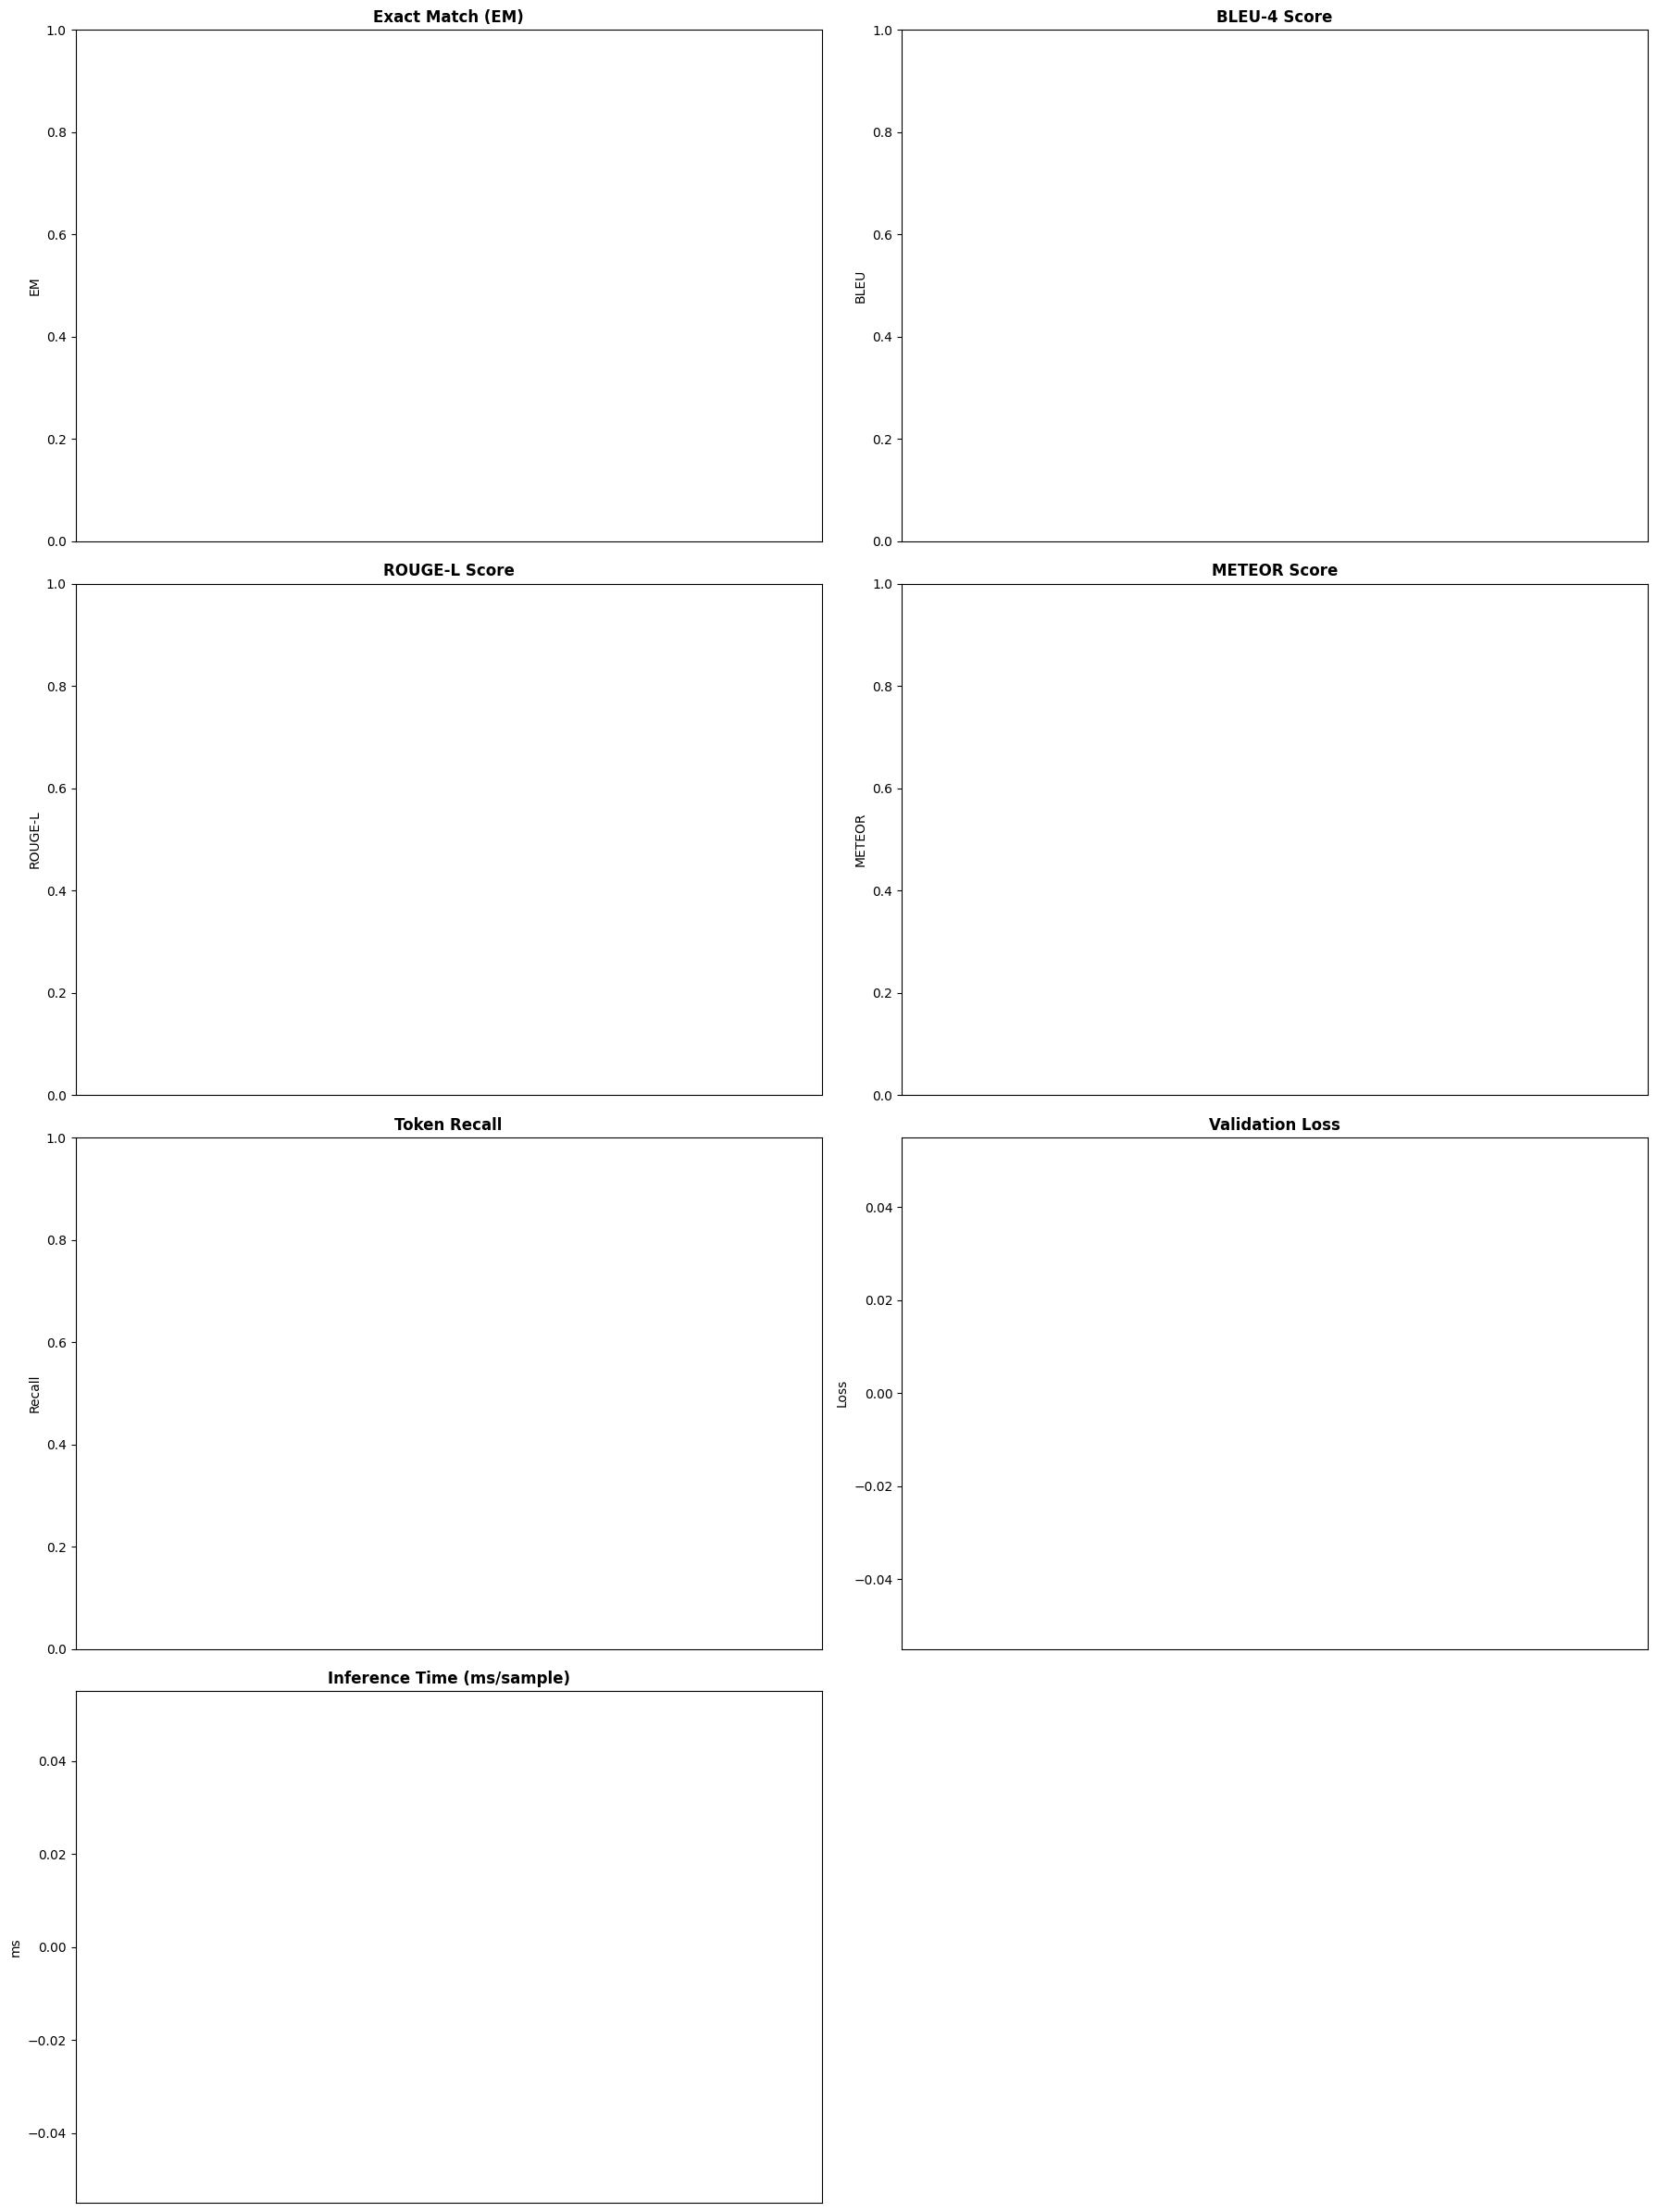

In [34]:
# BAR CHARTS — 7 METRICS
labels  = [r['checkpoint'].replace('best_vqa_model_', '').replace('.pth', '') for r in benchmark_results]
x       = range(len(labels))
metrics = [
    ([r['exact_match'] for r in benchmark_results], 'Exact Match (EM)', 'EM',       (0, 1.0)),
    ([r['bleu']        for r in benchmark_results], 'BLEU-4 Score',     'BLEU',     (0, 1.0)),
    ([r['rouge_l']     for r in benchmark_results], 'ROUGE-L Score',    'ROUGE-L',  (0, 1.0)),
    ([r['meteor']      for r in benchmark_results], 'METEOR Score',     'METEOR',   (0, 1.0)),
    ([r['recall']      for r in benchmark_results], 'Token Recall',     'Recall',   (0, 1.0)),
    ([r['val_loss']    for r in benchmark_results], 'Validation Loss',  'Loss',     None),
    ([r['sec_per_sample']*1000 for r in benchmark_results], 'Inference Time (ms/sample)', 'ms', None),
]
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()
for ax, (vals, title, ylabel, ylim) in zip(axes, metrics):
    bars = ax.bar(x, vals, color='steelblue', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
    if ylim: ax.set_ylim(*ylim)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
for ax in axes[len(metrics):]: ax.axis('off')
plt.tight_layout(); plt.show()


## BERTScore — Đánh giá tương đồng ngữ nghĩa

In [ ]:
from bert_score import score as calc_bert_score

In [ ]:
def evaluate_bertscore(model, dataloader, dataset, device, lang='vi', max_samples=500):
    """
    Tính BERTScore trên tập val để đánh giá tương đồng ngữ nghĩa.

    Thay vì so khớp bề mặt, BERTScore tính cosine similarity giữa
    contextual embedding token từ mBERT, phù hợp đánh giá B1/B2 nơi
    mô hình có thể paraphrase câu trả lời đúng nghĩa nhưng dùng từ khác.

    Args:
        model: VQAModel đã đưa về device.
        dataloader: DataLoader tập val.
        dataset: VQADataset.
        device: torch.device.
        lang: Ngôn ngữ BERTScore (mặc định 'vi' — tiếng Việt).
        max_samples: Giới hạn số mẫu để tiết kiệm thời gian.

    Returns:
        dict với keys: P (precision), R (recall), F1.
    """
    model.eval()
    preds_all, refs_all = [], []
    pad_idx = dataset.pad_idx
    count   = 0

    with torch.no_grad():
        for (images, questions, ans_in, ans_out, bboxes, bbox_mask) in tqdm(dataloader, desc='BERTScore'):
            if count >= max_samples: break
            images    = images.to(device); questions = questions.to(device)
            ans_out   = ans_out.to(device); bboxes    = bboxes.to(device)
            bbox_mask = bbox_mask.to(device)

            feat = model.encoder_img(images, bboxes, bbox_mask)
            q_h, q_c = model.encoder_q(questions)
            gen_out = model.decoder.generate(
                feat, q_h, q_c, max_len=dataset.max_seq_len,
                sos_idx=dataset.sos_idx, eos_idx=dataset.eos_idx,
                pad_idx=pad_idx, rep_penalty=3.0, return_alphas=True
            )
            gen = gen_out[0] if isinstance(gen_out, tuple) else gen_out

            for i in range(images.size(0)):
                pred_w = ids_to_words(gen[i].cpu().tolist(), dataset)
                tgt_w  = ids_to_words(ans_out[i].cpu().tolist(), dataset)
                preds_all.append(' '.join(pred_w).replace('_', ' '))
                refs_all.append(' '.join(tgt_w).replace('_', ' '))
                count += 1
            if count >= max_samples: break

    print(f'Computing BERTScore on {len(preds_all)} samples (lang={lang}) ...')
    P, R, F1 = calc_bert_score(preds_all, refs_all, lang=lang, verbose=False)
    result = {'P': P.mean().item(), 'R': R.mean().item(), 'F1': F1.mean().item()}
    print(f'BERTScore  P={result["P"]:.4f}  R={result["R"]:.4f}  F1={result["F1"]:.4f}')
    return result

# ── Chạy BERTScore trên A1:
# bertscore_a1 = evaluate_bertscore(model_a1, val_loader, val_dataset, device)


## LLM-as-a-judge — Đánh giá chất lượng câu trả lời bằng LLM

In [ ]:
import requests, json as _json

# ── Cấu hình NVIDIA API
NVIDIA_API_KEY  = "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"
NVIDIA_ENDPOINT = "https://integrate.api.nvidia.com/v1/chat/completions"
NVIDIA_MODEL    = "google/gemma-4-31b-it"

def _nvidia_chat(prompt: str, max_tokens: int = 128) -> str:
    """
    Gọi NVIDIA NIM API (chat/completions) và trả về text phản hồi.

    Args:
        prompt: Nội dung câu hỏi gửi cho LLM.
        max_tokens: Số token tối đa được sinh (mặc định 128).

    Returns:
        Chuỗi text phản hồi từ mô hình.
    """
    headers = {
        "Authorization": f"Bearer {NVIDIA_API_KEY}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    payload = {
        "model": NVIDIA_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": max_tokens,
        "temperature": 0.2,
        "top_p": 0.95,
        "stream": False,
    }
    resp = requests.post(NVIDIA_ENDPOINT, headers=headers, json=payload, timeout=60)
    resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"].strip()


def llm_as_judge(predictions: list, references: list, questions: list,
                 model: str = NVIDIA_MODEL,
                 max_samples: int = 50) -> dict:
    """
    Dùng LLM (NVIDIA NIM — Gemma-4-31B) đánh giá chất lượng câu trả lời VQA
    theo 3 tiêu chí:
        - Tính chính xác nội dung (correctness): 0–5.
        - Tính mạch lạc ngôn ngữ (fluency): 0–5.
        - Sự phù hợp với câu hỏi (relevance): 0–5.

    Phù hợp bổ sung cho B1 (zero-shot) và B2 (fine-tuned) nơi mô hình
    có thể paraphrase câu trả lời mà exact match hoặc n-gram không bắt được.

    Args:
        predictions: Danh sách câu trả lời dự đoán.
        references: Danh sách câu trả lời ground-truth.
        questions: Danh sách câu hỏi.
        model: Tên model NVIDIA NIM (không dùng trực tiếp, giữ API tương thích).
        max_samples: Số mẫu tối đa để đánh giá (mặc định 50).

    Returns:
        dict với keys: correctness, fluency, relevance (trung bình mỗi tiêu chí).
    """
    n = min(len(predictions), max_samples)
    scores = {'correctness': [], 'fluency': [], 'relevance': []}

    JUDGE_PROMPT = """Bạn là chuyên gia đánh giá hệ thống VQA (Visual Question Answering) tiếng Việt.
Đánh giá câu trả lời của mô hình so với câu trả lời chuẩn theo 3 tiêu chí, mỗi tiêu chí từ 0 đến 5:
- correctness: Nội dung có đúng với câu trả lời chuẩn không?
- fluency: Câu trả lời có mạch lạc, tự nhiên bằng tiếng Việt không?
- relevance: Câu trả lời có phù hợp với câu hỏi không?

Chỉ trả về JSON duy nhất, không giải thích thêm. Ví dụ: {{"correctness": 4, "fluency": 5, "relevance": 4}}

Câu hỏi: {question}
Câu trả lời chuẩn: {reference}
Câu trả lời mô hình: {prediction}
"""

    for i in tqdm(range(n), desc='LLM-as-judge (NVIDIA)'):
        prompt = JUDGE_PROMPT.format(
            question   = questions[i],
            reference  = references[i],
            prediction = predictions[i]
        )
        try:
            raw  = _nvidia_chat(prompt, max_tokens=64)
            # Trích JSON từ phản hồi (đề phòng model thêm text thừa)
            start = raw.find('{')
            end   = raw.rfind('}') + 1
            data  = json.loads(raw[start:end]) if start != -1 else {}
            for k in scores:
                scores[k].append(float(data.get(k, 0)))
        except Exception as e:
            print(f'  [warn] sample {i}: {e}')
            for k in scores: scores[k].append(0.0)

    result = {k: sum(v) / max(len(v), 1) for k, v in scores.items()}
    print(f'LLM-as-judge ({n} samples):',
          '  '.join(f'{k}={v:.2f}/5' for k, v in result.items()))
    return result

# ── Ví dụ sử dụng:
judge_result = llm_as_judge(predictions=preds_list, references=refs_list, questions=q_list)


## Ablation Study — FocalWeightedCELoss

In [ ]:
# ABLATION STUDY — FocalWeightedCELoss
# Tắt từng thành phần để đo đóng góp riêng lẻ

def run_ablation(vocab_size, word_weights, train_loader, val_loader, val_dataset,
                 device, num_epochs=5):
    """
    Ablation study trên FocalWeightedCELoss: tắt từng thành phần và so sánh.

    Các cấu hình ablation:
        full       — L = 0.7*Focal + 0.3*WCE + 0.3*FP_color + 0.2*FP_entity  (đầy đủ)
        no_focal   — alpha_mix=0 (chỉ WeightedCE)
        no_fp      — lambda_fp=0, lambda_fp_nc=0 (bỏ FP penalty)
        no_smooth  — label_smoothing=0 (bỏ label smoothing)
        plain_ce   — nn.CrossEntropyLoss tiêu chuẩn (baseline)

    Args:
        vocab_size: Kích thước bảng từ vựng.
        word_weights: Tensor trọng số token.
        train_loader, val_loader: DataLoader train/val.
        val_dataset: VQADataset.
        device: torch.device.
        num_epochs: Số epoch mỗi cấu hình (mặc định 5).

    Returns:
        dict {config_name: final_metrics}
    """
    ablation_configs = {
        'full'     : dict(alpha_mix=0.7, lambda_fp=0.3, lambda_fp_nc=0.2, label_smoothing=0.1),
        'no_focal' : dict(alpha_mix=0.0, lambda_fp=0.3, lambda_fp_nc=0.2, label_smoothing=0.1),
        'no_fp'    : dict(alpha_mix=0.7, lambda_fp=0.0, lambda_fp_nc=0.0, label_smoothing=0.1),
        'no_smooth': dict(alpha_mix=0.7, lambda_fp=0.3, lambda_fp_nc=0.2, label_smoothing=0.0),
    }

    ablation_results = {}
    for cfg_name, kwargs in ablation_configs.items():
        print(f'\n--- Ablation: {cfg_name} ---')
        crit = FocalWeightedCELoss(
            word_weights=word_weights, gamma=2.0, ignore_index=0,
            critical_indices=CRITICAL_INDICES, **kwargs
        ).to(device)
        m = VQAModel(vocab_size=vocab_size, decoder_type='lstm_att',
                     pretrained_cnn=True, trainable_cnn=False).to(device)
        opt = torch.optim.AdamW(m.parameters(), lr=5e-4, weight_decay=1e-4)

        for epoch in range(num_epochs):
            tfr = 0.9 - epoch * (0.8 / max(num_epochs - 1, 1))
            train_epoch(m, train_loader, crit, opt, device, teacher_forcing_ratio=tfr)

        metrics = evaluate(m, val_loader, val_dataset, crit, device)
        ablation_results[cfg_name] = metrics
        print(f'{cfg_name}: EM={metrics["exact_match"]:.4f} | BLEU={metrics["bleu"]:.4f} | ROUGE-L={metrics["rouge_l"]:.4f}')

    # Plain CE baseline
    print('\n--- Ablation: plain_ce ---')
    plain_crit = nn.CrossEntropyLoss(ignore_index=0)
    m_plain = VQAModel(vocab_size=vocab_size, decoder_type='lstm_att',
                       pretrained_cnn=True, trainable_cnn=False).to(device)
    opt_plain = torch.optim.AdamW(m_plain.parameters(), lr=5e-4, weight_decay=1e-4)
    for epoch in range(num_epochs):
        m_plain.train()
        for (imgs, qs, ai, ao, bb, bm) in tqdm(train_loader, leave=False):
            imgs=imgs.to(device); qs=qs.to(device); ai=ai.to(device); ao=ao.to(device)
            bb=bb.to(device); bm=bm.to(device)
            out, _ = m_plain(imgs, qs, ai, bb, bm)
            loss = plain_crit(out.view(-1, out.size(-1)), ao.view(-1))
            loss.backward(); opt_plain.step(); opt_plain.zero_grad()

    # Dùng FocalLoss chuẩn chỉ để đánh giá
    metrics_plain = evaluate(m_plain, val_loader, val_dataset,
                             FocalWeightedCELoss(word_weights, alpha_mix=0.7, lambda_fp=0.0, lambda_fp_nc=0.0).to(device),
                             device)
    ablation_results['plain_ce'] = metrics_plain
    print(f'plain_ce: EM={metrics_plain["exact_match"]:.4f} | BLEU={metrics_plain["bleu"]:.4f}')

    # Vẽ biểu đồ so sánh
    cfg_names = list(ablation_results.keys())
    em_vals   = [ablation_results[k]['exact_match'] for k in cfg_names]
    bleu_vals = [ablation_results[k]['bleu']        for k in cfg_names]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.bar(cfg_names, em_vals, color='teal', edgecolor='white')
    ax1.set_title('Exact Match per ablation config', fontweight='bold')
    ax1.set_ylabel('Exact Match')
    ax2.bar(cfg_names, bleu_vals, color='coral', edgecolor='white')
    ax2.set_title('BLEU-4 per ablation config', fontweight='bold')
    ax2.set_ylabel('BLEU-4')
    for ax, vals in [(ax1, em_vals), (ax2, bleu_vals)]:
        for bar, v in zip(ax.patches, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()
    return ablation_results

# ── Chạy ablation:
ablation_results = run_ablation(vocab_size, word_weights, train_loader, val_loader, val_dataset, device)


## So sánh tổng hợp 4 cấu hình A1, A2, B1, B2

In [ ]:
# BẢNG SO SÁNH A1 / A2 / B1 / B2
# Điền kết quả thực nghiệm vào dict bên dưới sau khi train xong

comparison_results = {
    'A1 (LSTM+Attn)' : {'em': 0.0, 'bleu': 0.0, 'rouge_l': 0.0, 'meteor': 0.0, 'recall': 0.0},
    'A2 (Transformer)': {'em': 0.0, 'bleu': 0.0, 'rouge_l': 0.0, 'meteor': 0.0, 'recall': 0.0},
    'B1 (Zero-shot)' : {'em': 0.0, 'bleu': 0.0, 'rouge_l': 0.0, 'meteor': 0.0, 'recall': 0.0},
    'B2 (LoRA FT)'   : {'em': 0.0, 'bleu': 0.0, 'rouge_l': 0.0, 'meteor': 0.0, 'recall': 0.0},
}

# ── Sau khi train, cập nhật từ history hoặc metrics dict:
if 'A1_pretrain_lstm_attention' in history:
    h = history['A1_pretrain_lstm_attention']
    comparison_results['A1 (LSTM+Attn)'] = {
        'em': h['em'][-1], 'bleu': h['bleu'][-1],
        'rouge_l': h['rouge_l'][-1], 'meteor': h['meteor'][-1], 'recall': h['recall'][-1]
    }

print('\n' + '='*75)
print(f"{'Config':<20} {'EM':>8} {'BLEU':>8} {'ROUGE-L':>9} {'METEOR':>8} {'Recall':>8}")
print('-'*75)
for cfg, m in comparison_results.items():
    print(f"{cfg:<20} {m['em']:>8.4f} {m['bleu']:>8.4f} {m['rouge_l']:>9.4f} {m['meteor']:>8.4f} {m['recall']:>8.4f}")
print('='*75)

# Biểu đồ radar so sánh 4 cấu hình
metric_keys = ['em', 'bleu', 'rouge_l', 'meteor', 'recall']
metric_labels = ['Exact Match', 'BLEU-4', 'ROUGE-L', 'METEOR', 'Recall']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
configs = list(comparison_results.keys())
for ax, mk, ml in zip(axes, metric_keys, metric_labels):
    vals = [comparison_results[c][mk] for c in configs]
    bars = ax.bar(range(len(configs)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels([c.split(' ')[0] for c in configs], fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title(ml, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('So sánh 4 cấu hình thực nghiệm: A1 · A2 · B1 · B2', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


---
# Cải thiện mô hình

In [ ]:
# ================================================================
# BEAM SEARCH — LSTM Decoder (A1: with attention / no-attention)
# Thay greedy decoding (argmax) bằng beam search beam_size=3
# để cải thiện chất lượng sinh chuỗi.
#
# Thuật toán:
#   - Duy trì k=beam_size chuỗi tốt nhất (theo log-prob tích lũy)
#   - Tại mỗi bước t, mở rộng mỗi beam bằng top-k token
#   - Giữ lại k beam có tổng log-prob cao nhất
#   - Dừng khi tất cả beam sinh ra EOS hoặc đạt max_len
# ================================================================

import heapq

def beam_search_lstm(
    decoder,
    img_f,
    q_h, q_c,
    max_len: int,
    sos_idx: int,
    eos_idx: int,
    pad_idx: int = 0,
    beam_size: int = 3,
    length_penalty: float = 0.7,
    rep_penalty: float = 2.0,
):
    """
    Beam Search cho LSTM decoder (DecoderNoAttention & DecoderWithAttention).

    Chỉ hỗ trợ batch_size=1 (single inference). Sử dụng trong evaluate()
    và test_single_input() thay greedy decoding.

    Args:
        decoder: DecoderNoAttention | DecoderWithAttention instance.
        img_f:   Tensor (1, 196, encoder_dim) — feature map ảnh.
        q_h, q_c: Tensor (1, hidden_dim) — hidden/cell state QuestionEncoder.
        max_len:   Độ dài tối đa chuỗi sinh.
        sos_idx, eos_idx, pad_idx: Index các special token.
        beam_size: Số beam duy trì song song (mặc định 3).
        length_penalty: Alpha LP — chia log-prob theo độ dài^alpha để
                         tránh thiên về câu ngắn (mặc định 0.7).
        rep_penalty: Hệ số penalty lặp từ (mặc định 2.0).

    Returns:
        Tensor (1, seq_len) — chuỗi token tốt nhất từ beam search.
    """
    import torch
    import torch.nn.functional as F

    device = img_f.device
    has_attn = hasattr(decoder, 'attention')
    ctx_fixed = None
    if not has_attn:
        ctx_fixed = img_f.mean(1)  # (1, enc_dim)

    # Beam: (log_prob, sequence_list, h, c, hist)
    init_h = q_h[0]  # (hidden_dim,)
    init_c = q_c[0]

    BeamState = {
        'log_prob': 0.0,
        'seq': [sos_idx],
        'h': init_h,
        'c': init_c,
        'done': False,
        'hist': [],
    }
    beams = [BeamState]

    completed = []

    for step in range(max_len):
        if not beams:
            break

        all_candidates = []
        for beam in beams:
            if beam['done']:
                completed.append(beam)
                continue

            cur = torch.tensor([beam['seq'][-1]], dtype=torch.long, device=device)
            h = beam['h'].unsqueeze(0)  # (1, hidden_dim)
            c = beam['c'].unsqueeze(0)

            emb = decoder.embedding(cur)  # (1, embed_dim)

            if has_attn:
                ctx, _ = decoder.attention(img_f, h)
            else:
                ctx = ctx_fixed

            lstm_in = torch.cat([emb, ctx], dim=1)  # (1, embed_dim+enc_dim)
            new_h, new_c = decoder.lstm_cell(lstm_in, (h, c))
            logits = decoder.fc(new_h)  # (1, vocab_size)

            # Repetition penalty
            logits_adj = logits.clone()
            for wi, cnt in {t: beam['hist'].count(t) for t in set(beam['hist'])}.items():
                pen = rep_penalty ** cnt
                logits_adj[0, wi] = logits_adj[0, wi] / pen if logits_adj[0, wi] > 0 else logits_adj[0, wi] * pen
            # Hard consecutive block
            prev = beam['seq'][-1]
            if prev not in (pad_idx, eos_idx, sos_idx):
                logits_adj[0, prev] -= 1e4

            log_probs = F.log_softmax(logits_adj, dim=-1)[0]  # (vocab_size,)
            topk_lp, topk_ids = torch.topk(log_probs, beam_size)

            for lp, tok in zip(topk_lp.tolist(), topk_ids.tolist()):
                new_seq = beam['seq'] + [tok]
                new_hist = beam['hist'] + ([tok] if tok not in (pad_idx, eos_idx, sos_idx) else [])
                new_lp = beam['log_prob'] + lp
                done = (tok == eos_idx)
                all_candidates.append({
                    'log_prob': new_lp,
                    'seq': new_seq,
                    'h': new_h[0],
                    'c': new_c[0],
                    'done': done,
                    'hist': new_hist,
                })

        if not all_candidates:
            break

        # Length-penalty score
        def score(b):
            lp_norm = ((5 + len(b['seq'])) / 6) ** length_penalty
            return b['log_prob'] / lp_norm

        all_candidates.sort(key=score, reverse=True)
        beams = [c for c in all_candidates if not c['done']][:beam_size]
        completed += [c for c in all_candidates if c['done']]

        # Giữ tối đa beam_size completed
        completed = sorted(completed, key=score, reverse=True)[:beam_size * 2]

    # Chọn best completed, fallback sang best beam
    pool = completed if completed else beams
    if not pool:
        return torch.tensor([[eos_idx]], device=device)

    def lp_score(b):
        lp_norm = ((5 + len(b['seq'])) / 6) ** length_penalty
        return b['log_prob'] / lp_norm

    best = max(pool, key=lp_score)
    seq = [t for t in best['seq'][1:] if t != eos_idx and t != pad_idx]  # drop SOS, EOS, PAD
    if not seq:
        seq = [eos_idx]
    return torch.tensor([seq], device=device)


print('✓ beam_search_lstm defined')


In [ ]:
# ================================================================
# BEAM SEARCH — Transformer Decoder (A2)
# ================================================================

def beam_search_transformer(
    decoder,
    img_f,
    max_len: int,
    sos_idx: int,
    eos_idx: int,
    pad_idx: int = 0,
    beam_size: int = 3,
    length_penalty: float = 0.7,
    rep_penalty: float = 2.0,
):
    """
    Beam Search cho TransformerDecoder (A2).

    Khác với LSTM, Transformer tính lại toàn bộ chuỗi tại mỗi bước;
    do đó beam được lưu dưới dạng tensor chuỗi đầy đủ, không cần cache
    hidden state.

    Args:
        decoder: TransformerDecoder instance.
        img_f:   Tensor (1, 196, encoder_dim).
        max_len, sos_idx, eos_idx, pad_idx, beam_size,
        length_penalty, rep_penalty: Giống beam_search_lstm.

    Returns:
        Tensor (1, seq_len) — chuỗi token tốt nhất.
    """
    import torch
    import torch.nn.functional as F

    device = img_f.device
    memory = decoder.memory_proj(img_f)  # (1, 196, hidden_dim)

    beams = [{
        'log_prob': 0.0,
        'seq': [sos_idx],
        'done': False,
        'hist': [],
    }]
    completed = []

    for step in range(max_len):
        if not beams:
            break

        all_candidates = []
        for beam in beams:
            if beam['done']:
                completed.append(beam)
                continue

            seq_t = torch.tensor([beam['seq']], dtype=torch.long, device=device)  # (1, T)
            T = seq_t.size(1)
            emb = decoder.embedding(seq_t) + decoder.pe[:, :T]  # (1, T, hidden_dim)
            causal_mask = decoder._causal_mask(T, device)
            out = decoder.transformer_decoder(emb, memory, tgt_mask=causal_mask)
            logits = decoder.fc(out[:, -1, :])  # (1, vocab_size)

            # Repetition penalty
            logits_adj = logits.clone()
            for wi, cnt in {t: beam['hist'].count(t) for t in set(beam['hist'])}.items():
                pen = rep_penalty ** cnt
                logits_adj[0, wi] = logits_adj[0, wi] / pen if logits_adj[0, wi] > 0 else logits_adj[0, wi] * pen
            prev = beam['seq'][-1]
            if prev not in (pad_idx, eos_idx, sos_idx):
                logits_adj[0, prev] -= 1e4

            log_probs = F.log_softmax(logits_adj, dim=-1)[0]
            topk_lp, topk_ids = torch.topk(log_probs, beam_size)

            for lp, tok in zip(topk_lp.tolist(), topk_ids.tolist()):
                new_seq = beam['seq'] + [tok]
                new_hist = beam['hist'] + ([tok] if tok not in (pad_idx, eos_idx, sos_idx) else [])
                all_candidates.append({
                    'log_prob': beam['log_prob'] + lp,
                    'seq': new_seq,
                    'done': (tok == eos_idx),
                    'hist': new_hist,
                })

        if not all_candidates:
            break

        def score(b):
            lp_norm = ((5 + len(b['seq'])) / 6) ** length_penalty
            return b['log_prob'] / lp_norm

        all_candidates.sort(key=score, reverse=True)
        beams = [c for c in all_candidates if not c['done']][:beam_size]
        completed += [c for c in all_candidates if c['done']]
        completed = sorted(completed, key=score, reverse=True)[:beam_size * 2]

    pool = completed if completed else beams
    if not pool:
        return torch.tensor([[eos_idx]], device=device)

    def lp_score(b):
        lp_norm = ((5 + len(b['seq'])) / 6) ** length_penalty
        return b['log_prob'] / lp_norm

    best = max(pool, key=lp_score)
    seq = [t for t in best['seq'][1:] if t != eos_idx and t != pad_idx]
    if not seq:
        seq = [eos_idx]
    return torch.tensor([seq], device=device)


# ── Hàm wrapper thống nhất: tự chọn beam search đúng loại decoder
def generate_with_beam(
    model,
    images, questions, bboxes, bbox_mask,
    dataset,
    beam_size: int = 3,
):
    """
    Wrapper thống nhất cho beam search — tự detect loại decoder.

    Hỗ trợ batch nhưng xử lý từng mẫu (do beam search chỉ hỗ trợ
    batch_size=1). Trả về danh sách chuỗi từ đã sinh.

    Args:
        model: VQAModel đã load checkpoint.
        images, questions, bboxes, bbox_mask: Tensor batch đã lên device.
        dataset: VQADataset.
        beam_size: Kích thước beam (mặc định 3).

    Returns:
        list[list[str]] — danh sách câu trả lời theo từng mẫu.
    """
    model.eval()
    B = images.size(0)
    results = []

    with torch.no_grad():
        feat_all  = model.encoder_img(images, bboxes, bbox_mask)
        q_h_all, q_c_all = model.encoder_q(questions)

    for i in range(B):
        feat_i = feat_all[i:i+1]
        q_h_i  = q_h_all[i:i+1]
        q_c_i  = q_c_all[i:i+1]

        with torch.no_grad():
            if model.decoder_type == 'transformer':
                gen = beam_search_transformer(
                    model.decoder, feat_i,
                    max_len=dataset.max_seq_len,
                    sos_idx=dataset.sos_idx,
                    eos_idx=dataset.eos_idx,
                    pad_idx=dataset.pad_idx,
                    beam_size=beam_size,
                )
            else:
                gen = beam_search_lstm(
                    model.decoder, feat_i, q_h_i, q_c_i,
                    max_len=dataset.max_seq_len,
                    sos_idx=dataset.sos_idx,
                    eos_idx=dataset.eos_idx,
                    pad_idx=dataset.pad_idx,
                    beam_size=beam_size,
                )

        pred_words = ids_to_words(gen[0].cpu().tolist(), dataset)
        results.append(pred_words)

    return results


print('✓ beam_search_transformer + generate_with_beam defined')


In [ ]:
# ================================================================
# EVALUATE VỚI BEAM SEARCH — so sánh trực tiếp vs greedy
# ================================================================

def evaluate_beam(
    model,
    dataloader,
    dataset,
    criterion,
    device,
    beam_size: int = 3,
):
    """
    Đánh giá mô hình dùng Beam Search decoding.

    Tính đủ 6 metrics (không tính loss vì beam search không có logits batch):
    exact_match, bleu, rouge_l, meteor, recall.

    Args:
        model: VQAModel.
        dataloader: DataLoader tập val/test.
        dataset: VQADataset.
        criterion: FocalWeightedCELoss.
        device: torch.device.
        beam_size: Kích thước beam (mặc định 3).

    Returns:
        dict: exact_match, bleu, rouge_l, meteor, recall.
    """
    smoother = SmoothingFunction().method4
    rscorer  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    bleu_list, rouge_list, meteor_list, recall_list = [], [], [], []
    exact_match = n_samples = 0

    for (images, questions, ans_in, ans_out, bboxes, bbox_mask) in tqdm(
            dataloader, desc=f'Beam Search (k={beam_size})', leave=False):
        images    = images.to(device)
        questions = questions.to(device)
        ans_out   = ans_out.to(device)
        bboxes    = bboxes.to(device)
        bbox_mask = bbox_mask.to(device)

        batch_preds = generate_with_beam(
            model, images, questions, bboxes, bbox_mask,
            dataset, beam_size=beam_size
        )

        for i in range(images.size(0)):
            pred_w = batch_preds[i]
            tgt_w  = ids_to_words(ans_out[i].cpu().tolist(), dataset)
            pred_str = ' '.join(pred_w)
            tgt_str  = ' '.join(tgt_w)

            if pred_w == tgt_w:
                exact_match += 1
            bleu_list.append(sentence_bleu([tgt_w], pred_w, smoothing_function=smoother))
            rout = rscorer.score(tgt_str, pred_str)
            rouge_list.append(rout['rougeL'].fmeasure)
            meteor_list.append(meteor_score([tgt_w], pred_w) if tgt_w else 0.0)
            recall_list.append(
                len(set(pred_w) & set(tgt_w)) / len(set(tgt_w)) if tgt_w else 0.0
            )
            n_samples += 1

    n = max(n_samples, 1)
    return {
        'exact_match': exact_match / n,
        'bleu'       : sum(bleu_list)   / n,
        'rouge_l'    : sum(rouge_list)  / n,
        'meteor'     : sum(meteor_list) / n,
        'recall'     : sum(recall_list) / n,
    }


# ── Chạy so sánh greedy vs beam search
# Bỏ comment sau khi đã train xong model_a1 và model_a2

# print('=== So sánh Greedy vs Beam Search ===')
# for model_obj, name in [(model_a1, 'A1_lstm_att'), (model_a2, 'A2_transformer')]:
#     m_greedy = evaluate(model_obj, val_loader, val_dataset, criterion, device)
#     m_beam   = evaluate_beam(model_obj, val_loader, val_dataset, criterion, device, beam_size=3)
#     print(f'\n[{name}]')
#     print(f'  Greedy  — EM={m_greedy["exact_match"]:.4f}  BLEU={m_greedy["bleu"]:.4f}  ROUGE-L={m_greedy["rouge_l"]:.4f}')
#     print(f'  Beam(3) — EM={m_beam["exact_match"]:.4f}  BLEU={m_beam["bleu"]:.4f}  ROUGE-L={m_beam["rouge_l"]:.4f}')

print('✓ evaluate_beam defined')


In [ ]:
# ================================================================
# FINE-TUNING MỘT PHẦN RESNET50
# Unfreeze 2 block cuối (layer3, layer4) thay vì frozen hoàn toàn.
# Giúp mô hình học đặc trưng thị giác thích nghi với domain múa lân.
# ================================================================

def unfreeze_resnet_last_n_blocks(image_encoder, n_blocks: int = 2):
    """
    Unfreeze n block cuối của ResNet50 trong ImageEncoder.

    ResNet50 gồm 8 khối chính (theo thứ tự children):
        0: conv1   1: bn1    2: relu   3: maxpool
        4: layer1  5: layer2 6: layer3 7: layer4

    Với n_blocks=2, layer3 (idx=6) và layer4 (idx=7) được unfreeze.
    Projection + LayerNorm + BBoxSpatialAttention luôn trainable.

    Args:
        image_encoder: ImageEncoder instance.
        n_blocks: Số ResNet block cuối cần unfreeze (mặc định 2).

    Returns:
        int — số tham số trainable mới được bật.
    """
    # Freeze tất cả ResNet trước
    for p in image_encoder.resnet.parameters():
        p.requires_grad = False

    # Unfreeze n block cuối
    children = list(image_encoder.resnet.children())
    blocks_to_unfreeze = children[-n_blocks:]  # layer3, layer4 nếu n=2
    for block in blocks_to_unfreeze:
        for p in block.parameters():
            p.requires_grad = True

    image_encoder.trainable_cnn = True
    n_trainable = sum(p.numel() for p in image_encoder.parameters() if p.requires_grad)
    print(f'✓ Unfroze last {n_blocks} ResNet blocks | Trainable params in encoder: {n_trainable:,}')
    return n_trainable


# ── Tạo model A1 với partial ResNet finetune
model_name_a1_ft = 'A1_pretrain_lstm_att_resnet_ft'
model_a1_ft = VQAModel(
    vocab_size    = vocab_size,
    decoder_type  = 'lstm_att',
    pretrained_cnn= True,
    trainable_cnn = False,
).to(device)

# Unfreeze 2 block cuối ResNet50
unfreeze_resnet_last_n_blocks(model_a1_ft.encoder_img, n_blocks=2)

# Dùng LR khác nhau cho backbone (nhỏ hơn) và các layer mới
optimizer_a1_ft = torch.optim.AdamW([
    {'params': model_a1_ft.encoder_img.resnet.parameters(), 'lr': 5e-5},   # ResNet backbone — LR nhỏ
    {'params': [
        *model_a1_ft.encoder_img.projection.parameters(),
        *model_a1_ft.encoder_img.layer_norm.parameters(),
        *model_a1_ft.encoder_img.bbox_attn.parameters(),
        *model_a1_ft.encoder_q.parameters(),
        *model_a1_ft.decoder.parameters(),
    ], 'lr': 5e-4},  # Các layer mới — LR lớn hơn
], weight_decay=1e-4)

n_params = sum(p.numel() for p in model_a1_ft.parameters() if p.requires_grad)
print(f'Ready: {model_name_a1_ft}  |  Total trainable: {n_params:,} params')
print('# Gọi: training(model_a1_ft, model_name_a1_ft, optimizer_a1_ft, num_epochs=20)')


In [ ]:
# ================================================================
# DATA AUGMENTATION
# Flip, ColorJitter, RandomCrop cho ảnh
# Template-based paraphrase + back-translation placeholder cho câu hỏi
# ================================================================

import torchvision.transforms as transforms
import random as _random

# ── Augmented transform cho tập train
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.80, 1.0),    # crop 80–100% ảnh gốc
        ratio=(0.9, 1.1),
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.08,
    ),
    transforms.RandomGrayscale(p=0.05),   # 5% xác suất -> ảnh grayscale
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


# ── Question paraphrase (template-based cho tiếng Việt)
# Paraphrase đơn giản bằng cách thay thế cụm từ tương đương
PARAPHRASE_MAP = [
    # (pattern, [alternatives])
    ('màu gì',       ['màu sắc gì',     'có màu nào',         'mang màu gì']),
    ('màu sắc gì',   ['màu gì',         'có màu nào']),
    ('có mấy',       ['bao nhiêu',      'tổng cộng mấy']),
    ('bao nhiêu',    ['có mấy',         'tổng số bao nhiêu']),
    ('làm gì',       ['đang làm gì',    'thực hiện hành động gì']),
    ('đang làm gì',  ['làm gì',         'đang thực hiện gì']),
    ('trong ảnh',    ['trong hình',     'trong bức ảnh này']),
    ('trong hình',   ['trong ảnh',      'trong bức hình này']),
    ('con lân',      ['con lân múa',    'linh vật lân']),
    ('linh vật lân', ['con lân',        'con lân này']),
    ('người biểu diễn', ['người chơi lân', 'diễn viên']),
]

def paraphrase_question(question: str, p: float = 0.5) -> str:
    """
    Paraphrase câu hỏi bằng cách thay thế ngẫu nhiên các cụm từ tương đương.

    Với xác suất p, áp dụng mỗi rule paraphrase nếu cụm từ xuất hiện trong
    câu hỏi. Giữ nguyên câu nếu không có rule nào khớp.

    Args:
        question: Câu hỏi gốc tiếng Việt.
        p: Xác suất áp dụng mỗi rule (mặc định 0.5).

    Returns:
        Câu hỏi đã được paraphrase (hoặc giữ nguyên).
    """
    q = question.lower().strip()
    for pattern, alternatives in PARAPHRASE_MAP:
        if pattern in q and _random.random() < p:
            q = q.replace(pattern, _random.choice(alternatives), 1)
    # Đảm bảo kết thúc bằng '?'
    if q and not q.endswith('?'):
        q = q.rstrip('.') + '?'
    return q


# ── AugmentedVQADataset: kế thừa VQADataset, thêm augmentation
class AugmentedVQADataset(VQADataset):
    """
    VQADataset mở rộng với Data Augmentation cho cả ảnh lẫn câu hỏi.

    Augmentation ảnh:
        - RandomResizedCrop(224, scale=[0.8, 1.0])
        - RandomHorizontalFlip(p=0.5)
        - ColorJitter(brightness, contrast, saturation, hue)
        - RandomGrayscale(p=0.05)

    Augmentation câu hỏi:
        - Template-based paraphrase (p_aug xác suất áp dụng).

    Args:
        Giống VQADataset.
        augment: True để bật augmentation (mặc định True).
        p_question_aug: Xác suất paraphrase câu hỏi (mặc định 0.4).
    """
    def __init__(self, *args, augment: bool = True,
                 p_question_aug: float = 0.4, **kwargs):
        kwargs.setdefault('transform', train_transform_aug if augment else None)
        super().__init__(*args, **kwargs)
        self.augment = augment
        self.p_question_aug = p_question_aug

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.img_dir, item['image_path'])
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224))
        image = self.transform(image)

        # Question augmentation
        question = item['question']
        if self.augment and _random.random() < self.p_question_aug:
            question = paraphrase_question(question, p=0.6)

        q_t     = self.tokenize_and_pad(question)
        ans_in  = self.tokenize_and_pad(item['answer'], add_sos=True)
        ans_out = self.tokenize_and_pad(item['answer'], add_eos=True)
        bboxes, bbox_mask = self.parse_bboxes(item)
        return image, q_t, ans_in, ans_out, bboxes, bbox_mask


# ── Tạo augmented train loader
train_dataset_aug = AugmentedVQADataset(
    f'{path}/train.json', f'{path}/word_vocab.json',
    img_dir=os.path.join(path, 'images'),
    augment=True, p_question_aug=0.4,
)
train_loader_aug = DataLoader(
    train_dataset_aug, batch_size=4, shuffle=True,
    num_workers=2, pin_memory=True,
)
print(f'✓ AugmentedVQADataset | train = {len(train_dataset_aug)} samples')
print('  Dùng train_loader_aug thay train_loader khi gọi training()')


In [ ]:
# ================================================================
# SIGLIPV2 IMAGE ENCODER
# Thay thế ResNet50 bằng SigLIPv2 (google/siglip2-base-patch16-224)
# để đánh giá khả năng trích xuất đặc trưng trên domain múa lân.
#
# SigLIPv2 dùng contrastive pretraining image-text (như CLIP) với
# sigmoid loss, cho đặc trưng ngữ nghĩa phong phú hơn ResNet50.
# Patch 16x16 → 196 patch tokens (14x14) → tương thích với A1/A2.
# ================================================================

# !pip install transformers>=4.40 -q  # đã cài ở bước 3

from transformers import AutoModel

class SigLIPv2ImageEncoder(nn.Module):
    """
    Image encoder dựa trên SigLIPv2 (google/siglip2-base-patch16-224).

    SigLIPv2 trả về sequence_output hình dạng (B, 196, 768) —
    196 patch token (14x14), mỗi token 768 chiều.
    Module này chiếu xuống hidden_dim (512) và tích hợp BBoxSpatialAttention.

    Tương thích hoàn toàn với API của ImageEncoder gốc:
        forward(images, bboxes, bbox_mask) -> (B, 196, hidden_dim)

    Args:
        model_id: HuggingFace model ID (mặc định 'google/siglip2-base-patch16-224').
        hidden_dim: Số chiều sau projection (mặc định 512).
        trainable: Cho phép finetune SigLIPv2 backbone (mặc định False).
        trainable_last_n: Số transformer block cuối được unfreeze.
                          0 = frozen hoàn toàn, -1 = full finetune (mặc định 0).
    """
    MODEL_DIM = 768

    def __init__(
        self,
        model_id: str = 'google/siglip2-base-patch16-224',
        hidden_dim: int = 512,
        trainable: bool = False,
        trainable_last_n: int = 0,
    ):
        super().__init__()
        print(f'Loading SigLIPv2 from {model_id} ...')
        self.backbone = AutoModel.from_pretrained(model_id)
        self.feature_dim = hidden_dim

        # Freeze/Unfreeze
        for p in self.backbone.parameters():
            p.requires_grad = False

        if trainable_last_n > 0:
            # Unfreeze last N transformer blocks (vision_model.encoder.layers)
            try:
                layers = self.backbone.vision_model.encoder.layers
                for layer in layers[-trainable_last_n:]:
                    for p in layer.parameters():
                        p.requires_grad = True
                print(f'  Unfroze last {trainable_last_n} SigLIPv2 blocks')
            except AttributeError:
                print('  WARNING: Could not locate SigLIPv2 encoder layers.')
        elif trainable:
            for p in self.backbone.parameters():
                p.requires_grad = True

        self.projection  = nn.Linear(self.MODEL_DIM, hidden_dim)
        self.layer_norm  = nn.LayerNorm(hidden_dim)
        self.bbox_attn   = BBoxSpatialAttention(grid_size=14, hidden_dim=hidden_dim)

        n_trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  SigLIPv2Encoder | Trainable: {n_trainable:,} params')

    def forward(self, images, bboxes=None, bbox_mask=None):
        """
        Trích xuất 196 patch feature từ SigLIPv2.

        Args:
            images: Tensor (B, 3, 224, 224) — cần dùng SigLIP preprocessor,
                    nhưng ở đây dùng ImageNet normalize vì resize đã 224x224.
            bboxes: Tensor (B, max_boxes, 5) hoặc None.
            bbox_mask: Tensor (B, max_boxes) hoặc None.

        Returns:
            Tensor (B, 196, hidden_dim).
        """
        with torch.set_grad_enabled(any(p.requires_grad for p in self.backbone.parameters())):
            outputs = self.backbone.vision_model(
                pixel_values=images,
                output_hidden_states=False,
            )
            # last_hidden_state: (B, 196+1, 768) — có thể có [CLS] token đầu
            feat = outputs.last_hidden_state
            if feat.size(1) == 197:   # có CLS token
                feat = feat[:, 1:, :]  # bỏ CLS, giữ 196 patches

        feat = self.layer_norm(self.projection(feat))   # (B, 196, hidden_dim)
        if bboxes is not None and bbox_mask is not None:
            feat = self.bbox_attn(feat, bboxes, bbox_mask)
        return feat


class VQAModelSigLIP(nn.Module):
    """
    VQAModel thay ImageEncoder (ResNet50) bằng SigLIPv2ImageEncoder.

    Giữ nguyên QuestionEncoder và Decoder — chỉ swap image encoder
    để đánh giá đóng góp của SigLIPv2 so với ResNet50.

    Args:
        Giống VQAModel.
        siglip_model_id: HuggingFace ID của SigLIPv2 model.
        siglip_trainable_last_n: Số block cuối SigLIPv2 được unfreeze.
    """
    def __init__(
        self,
        vocab_size,
        embed_dim=256,
        hidden_dim=512,
        attention_dim=512,
        decoder_type='lstm_att',
        siglip_model_id='google/siglip2-base-patch16-224',
        siglip_trainable_last_n=0,
    ):
        super().__init__()
        self.encoder_img = SigLIPv2ImageEncoder(
            model_id=siglip_model_id,
            hidden_dim=hidden_dim,
            trainable_last_n=siglip_trainable_last_n,
        )
        self.encoder_q   = QuestionEncoder(vocab_size, embed_dim, hidden_dim)
        self.decoder_type = decoder_type
        enc_dim = hidden_dim
        if decoder_type == 'lstm_att':
            self.decoder = DecoderWithAttention(vocab_size, embed_dim, hidden_dim, enc_dim, attention_dim)
        elif decoder_type == 'lstm_noatt':
            self.decoder = DecoderNoAttention(vocab_size, embed_dim, hidden_dim, enc_dim)
        else:
            self.decoder = TransformerDecoder(vocab_size, embed_dim, hidden_dim, enc_dim)

    def forward(self, images, questions, answers, bboxes=None, bbox_mask=None, teacher_forcing_ratio=0.5):
        f = self.encoder_img(images, bboxes, bbox_mask)
        q_h, q_c = self.encoder_q(questions)
        out, alphas = self.decoder(f, q_h, q_c, answers, tfr=teacher_forcing_ratio)
        return out, alphas


# ── Khởi tạo model SigLIPv2 + LSTM Attention
# Uncomment để chạy (yêu cầu download ~400MB model)
# model_name_siglip = 'A1_siglip_lstm_att'
# model_siglip = VQAModelSigLIP(
#     vocab_size=vocab_size,
#     decoder_type='lstm_att',
#     siglip_trainable_last_n=2,   # Unfreeze 2 block cuối SigLIPv2
# ).to(device)
# optimizer_siglip = torch.optim.AdamW([
#     {'params': model_siglip.encoder_img.backbone.parameters(), 'lr': 1e-5},
#     {'params': [*model_siglip.encoder_img.projection.parameters(),
#                 *model_siglip.encoder_img.layer_norm.parameters(),
#                 *model_siglip.encoder_img.bbox_attn.parameters(),
#                 *model_siglip.encoder_q.parameters(),
#                 *model_siglip.decoder.parameters()], 'lr': 5e-4},
# ], weight_decay=1e-4)
# print(f'Ready: {model_name_siglip}')

print('✓ SigLIPv2ImageEncoder + VQAModelSigLIP defined')


---
## Direct Preference Optimization (DPO)

DPO là phương pháp **Reinforcement Learning từ Human Feedback (RLHF) đơn giản hóa**:
- Không cần reward model riêng biệt
- Trực tiếp tối ưu policy theo **454 preference pairs** được annotation thủ công
- Format dữ liệu: `{image_path, question, chosen, rejected}`
- **Reward = VQA Accuracy × BERTScore** (dùng để đánh giá, không dùng trong loss)


In [ ]:
# ================================================================
# DPO — PREFERENCE DATASET
# Load 454 cặp (chosen, rejected) đã được annotation thủ công.
# Tokenize bằng word_vocab gốc (giống VQADataset).
# ================================================================

class DPOPreferenceDataset(torch.utils.data.Dataset):
    """
    Dataset cho DPO với preference pairs đã được annotation thủ công.

    Đọc file JSON gồm 454 mẫu, mỗi mẫu có cấu trúc:
        {
            "image_path": "images/xxx.jpg",
            "question":   "...",
            "chosen":     "câu trả lời tốt hơn",
            "rejected":   "câu trả lời tệ hơn"
        }

    Pipeline xử lý cho mỗi mẫu:
        1. Load ảnh và apply transform (không augmentation).
        2. Tokenize question, chosen, rejected bằng word_vocab.
        3. chosen_in  = [SOS] + chosen_tokens  (input decoder)
        4. rejected_in = [SOS] + rejected_tokens
        5. Parse bbox (nếu có trường 'bbox' trong JSON, không bắt buộc).

    Args:
        json_path:   Đường dẫn file preference JSON (454 mẫu).
        vocab_path:  Đường dẫn word_vocab.json.
        img_dir:     Thư mục gốc chứa ảnh.
        max_seq_len: Độ dài tối đa chuỗi token (mặc định 30).
        transform:   Transform ảnh (mặc định: Resize+Normalize ImageNet).
    """
    def __init__(
        self,
        json_path: str,
        vocab_path: str,
        img_dir: str = '',
        max_seq_len: int = 30,
        transform=None,
    ):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)
        with open(vocab_path, 'r', encoding='utf-8') as f:
            self.word_vocab = json.load(f)

        self.pad_idx = self.word_vocab.get('<PAD>', 0)
        self.unk_idx = self.word_vocab.get('<UNK>', 1)
        self.sos_idx = self.word_vocab.get('<SOS>', 2)
        self.eos_idx = self.word_vocab.get('<EOS>', 3)
        self.idx2word = {v: k for k, v in self.word_vocab.items()}

        self.img_dir    = img_dir
        self.max_seq_len = max_seq_len
        self.transform  = transform if transform else transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std=[0.229,0.224,0.225]),
        ])

        print(f'✓ DPOPreferenceDataset loaded: {len(self.data)} pairs')
        self._validate()

    def _validate(self):
        """Kiểm tra format và báo lỗi mẫu bị thiếu trường."""
        required = {'image_path', 'question', 'chosen', 'rejected'}
        bad = [i for i, d in enumerate(self.data) if not required.issubset(d.keys())]
        if bad:
            print(f'  WARNING: {len(bad)} samples missing required fields: {bad[:5]}...')
        chosen_lens   = [len(d['chosen'].split())   for d in self.data]
        rejected_lens = [len(d['rejected'].split()) for d in self.data]
        print(f'  Chosen   avg tokens: {sum(chosen_lens)/len(chosen_lens):.1f}')
        print(f'  Rejected avg tokens: {sum(rejected_lens)/len(rejected_lens):.1f}')

    def _tokenize_pad(self, text: str, add_sos=False, add_eos=False) -> torch.Tensor:
        """
        Tokenize + pad/trunc text về max_seq_len.
        Áp dụng normalize_special_phrases trước khi tách từ.
        """
        text = normalize_special_phrases(str(text).lower())
        text = re.sub(r'[^\w\s_]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = [self.word_vocab.get(w, self.unk_idx) for w in text.split()]
        seq = []
        if add_sos:
            seq.append(self.sos_idx)
        seq.extend(tokens)
        if add_eos:
            seq.append(self.eos_idx)
        # Pad hoặc truncate
        if len(seq) < self.max_seq_len:
            seq += [self.pad_idx] * (self.max_seq_len - len(seq))
        else:
            seq = seq[:self.max_seq_len]
        return torch.tensor(seq, dtype=torch.long)

    def _parse_bboxes(self, item):
        """Parse bbox nếu có, ngược lại trả về bbox toàn ảnh mặc định."""
        raw = item.get('bbox', {})
        boxes_flat = []
        for category, class_id in BBOX_CLASS.items():
            for box in raw.get(category, []):
                if len(box) >= 4:
                    boxes_flat.append([float(class_id)] + [float(v) for v in box[:4]])
        if not boxes_flat:
            boxes_flat = [[0.0, 0.5, 0.5, 1.0, 1.0]]
        boxes_flat = boxes_flat[:MAX_BOXES]
        arr  = np.zeros((MAX_BOXES, 5), dtype=np.float32)
        mask = np.zeros(MAX_BOXES, dtype=np.float32)
        for i, b in enumerate(boxes_flat):
            arr[i] = b; mask[i] = 1.0
        return torch.tensor(arr, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d        = self.data[idx]
        img_path = os.path.join(self.img_dir, d['image_path'])
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224))
        image = self.transform(image)

        # Tokenize question (không SOS/EOS — dùng cho QuestionEncoder)
        question    = self._tokenize_pad(d['question'])

        # Tokenize chosen / rejected — dạng decoder input (SOS ở đầu)
        chosen_in   = self._tokenize_pad(d['chosen'],   add_sos=True)
        rejected_in = self._tokenize_pad(d['rejected'], add_sos=True)

        # Target (EOS ở cuối) — dùng để tính log-prob sequence
        chosen_out   = self._tokenize_pad(d['chosen'],   add_eos=True)
        rejected_out = self._tokenize_pad(d['rejected'], add_eos=True)

        bboxes, bbox_mask = self._parse_bboxes(d)

        return (
            image,          # (3, 224, 224)
            question,       # (max_seq_len,)
            chosen_in,      # (max_seq_len,)  decoder input chosen
            rejected_in,    # (max_seq_len,)  decoder input rejected
            chosen_out,     # (max_seq_len,)  target chosen (for log-prob)
            rejected_out,   # (max_seq_len,)  target rejected
            bboxes,         # (MAX_BOXES, 5)
            bbox_mask,      # (MAX_BOXES,)
        )


# ── Preview dataset (chạy sau khi có file dpo_preference.json)
# dpo_pref_ds = DPOPreferenceDataset(
#     json_path = os.path.join(path, 'dpo_preference.json'),
#     vocab_path = os.path.join(path, 'word_vocab.json'),
#     img_dir   = os.path.join(path, 'images'),
#     max_seq_len = 30,
# )
# img, q, cin, rin, cout, rout, bb, bm = dpo_pref_ds[0]
# print('chosen_in :', dpo_pref_ds.idx2word.get(int(cin[0]), '?'), '...')
# print('rejected_in:', dpo_pref_ds.idx2word.get(int(rin[0]), '?'), '...')

print('✓ DPOPreferenceDataset defined')


In [ ]:
# ================================================================
# DPO LOSS
# Direct Preference Optimization (Rafailov et al., 2023)
#
# L_DPO = -E[log σ(β*(log π_θ(y_w|x)/π_ref(y_w|x)
#                   - log π_θ(y_l|x)/π_ref(y_l|x)))]
# ================================================================

import copy

class DPOLoss(nn.Module):
    """
    Direct Preference Optimization loss.

    Tính log-probability của toàn bộ chuỗi (chosen hoặc rejected) dưới
    policy model và reference model, rồi tối ưu hóa bằng sigmoid loss.

    Công thức:
        r_w = log π_θ(y_w|x) - log π_ref(y_w|x)
        r_l = log π_θ(y_l|x) - log π_ref(y_l|x)
        L   = -log σ(β * (r_w - r_l))

    Args:
        beta: KL-penalty coefficient (mặc định 0.1).
              Beta thấp → học mạnh từ preference.
              Beta cao  → giữ gần SFT.
        pad_idx: Index PAD, bỏ qua khi tính log-prob.
    """
    def __init__(self, beta: float = 0.1, pad_idx: int = 0):
        super().__init__()
        self.beta    = beta
        self.pad_idx = pad_idx

    def _seq_log_prob(
        self,
        model,
        images, questions,
        decoder_in,   # [SOS] + answer tokens  → input cho decoder
        target_out,   # answer tokens + [EOS]  → target để gather log-prob
        bboxes, bbox_mask,
    ) -> torch.Tensor:
        """
        Tính tổng log-probability của chuỗi target_out dưới model.

        Dùng teacher forcing (tfr=1.0): decoder luôn nhận đúng token
        ở bước trước (teacher forcing), logits được so sánh với target_out.

        Args:
            model: VQAModel (policy hoặc reference).
            images, questions, bboxes, bbox_mask: Batch tensors.
            decoder_in:  Tensor (B, T) — [SOS] + answer (decoder input).
            target_out:  Tensor (B, T) — answer + [EOS] (gather target).

        Returns:
            Tensor (B,) — tổng log-prob theo chuỗi (PAD bị mask = 0).
        """
        with torch.set_grad_enabled(model.training):
            logits, _ = model(
                images, questions, decoder_in,
                bboxes, bbox_mask,
                teacher_forcing_ratio=1.0,
            )
        # logits: (B, T, V)
        log_probs = torch.log_softmax(logits, dim=-1)       # (B, T, V)

        # Căn chỉnh target về đúng chiều T của logits
        T_logit = logits.size(1)
        T_tgt   = target_out.size(1)
        if T_tgt > T_logit:
            target_out = target_out[:, :T_logit]
        elif T_tgt < T_logit:
            pad = torch.full(
                (target_out.size(0), T_logit - T_tgt),
                self.pad_idx, dtype=torch.long, device=target_out.device
            )
            target_out = torch.cat([target_out, pad], dim=1)

        # Gather log-prob tại vị trí đúng token
        V   = logits.size(-1)
        idx = target_out.clamp(0, V - 1).unsqueeze(2)       # (B, T, 1)
        tok_lp = log_probs.gather(2, idx).squeeze(2)         # (B, T)

        # Mask PAD (không tính loss tại vị trí padding)
        mask = (target_out != self.pad_idx).float()
        return (tok_lp * mask).sum(dim=1)                    # (B,)

    def forward(
        self,
        policy_model,
        ref_model,
        images, questions,
        chosen_in,   chosen_out,
        rejected_in, rejected_out,
        bboxes, bbox_mask,
    ):
        """
        Tính DPO loss và reward margin cho một batch.

        Args:
            policy_model: VQAModel đang train (gradient được tính).
            ref_model:    VQAModel frozen (SFT checkpoint).
            images:       (B, 3, 224, 224)
            questions:    (B, q_len)
            chosen_in:    (B, T) — [SOS] + chosen tokens
            chosen_out:   (B, T) — chosen tokens + [EOS]
            rejected_in:  (B, T) — [SOS] + rejected tokens
            rejected_out: (B, T) — rejected tokens + [EOS]
            bboxes:       (B, MAX_BOXES, 5)
            bbox_mask:    (B, MAX_BOXES)

        Returns:
            Tuple (loss, reward_margin, reward_chosen, reward_rejected):
                loss            — DPO loss scalar.
                reward_margin   — mean(r_w - r_l), dùng monitor training.
                reward_chosen   — mean(r_w), đo mức độ prefer chosen.
                reward_rejected — mean(r_l), đo mức độ disfavor rejected.
        """
        # ── Policy log-probs (gradient ON)
        lp_w_pi = self._seq_log_prob(
            policy_model, images, questions,
            chosen_in, chosen_out, bboxes, bbox_mask
        )
        lp_l_pi = self._seq_log_prob(
            policy_model, images, questions,
            rejected_in, rejected_out, bboxes, bbox_mask
        )

        # ── Reference log-probs (gradient OFF)
        with torch.no_grad():
            lp_w_ref = self._seq_log_prob(
                ref_model, images, questions,
                chosen_in, chosen_out, bboxes, bbox_mask
            )
            lp_l_ref = self._seq_log_prob(
                ref_model, images, questions,
                rejected_in, rejected_out, bboxes, bbox_mask
            )

        r_w = lp_w_pi - lp_w_ref   # (B,)  implicit reward chosen
        r_l = lp_l_pi - lp_l_ref   # (B,)  implicit reward rejected

        # DPO loss = -log σ(β*(r_w - r_l))
        loss = -F.logsigmoid(self.beta * (r_w - r_l)).mean()

        return (
            loss,
            (r_w - r_l).mean().item(),
            r_w.mean().item(),
            r_l.mean().item(),
        )


print('✓ DPOLoss defined')


In [ ]:
# ================================================================
# train_dpo — phiên bản verbose (logging chi tiết)
# ================================================================

def train_dpo(
    policy_model,
    ref_model,
    dpo_dataset,
    device,
    num_epochs: int = 5,
    batch_size: int = 4,
    lr: float = 1e-5,
    beta: float = 0.1,
    warmup_steps: int = 20,
    grad_clip: float = 1.0,
    save_path: str = None,
    eval_every: int = 1,
    val_loader=None,
    val_dataset=None,
    criterion=None,
    log_every: int = 10,
):
    import time

    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad = False

    dpo_loader = torch.utils.data.DataLoader(
        dpo_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True, drop_last=False,
    )
    dpo_loss_fn = DPOLoss(beta=beta, pad_idx=dpo_dataset.pad_idx)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, policy_model.parameters()),
        lr=lr, weight_decay=1e-5, betas=(0.9, 0.999), eps=1e-8,
    )
    total_steps = num_epochs * len(dpo_loader)
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return max(0.05, 0.5 * (1 + np.cos(np.pi * progress)))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = []
    best_margin = -float('inf')
    global_step = 0
    ACCUM = 2
    n_params = sum(p.numel() for p in policy_model.parameters() if p.requires_grad)
    steps_per_epoch = len(dpo_loader)

    # ── Header
    print('\n' + '='*70)
    print('  DPO TRAINING — VERBOSE MODE')
    print('='*70)
    print(f'  Pairs        : {len(dpo_dataset)}')
    print(f'  Epochs       : {num_epochs}')
    print(f'  Batch size   : {batch_size}  (accum={ACCUM} -> effective={batch_size*ACCUM})')
    print(f'  Steps/epoch  : {steps_per_epoch}  (total={total_steps})')
    print(f'  LR (peak)    : {lr:.2e}  |  Warmup: {warmup_steps} steps')
    print(f'  Beta (KL)    : {beta}')
    print(f'  Grad clip    : {grad_clip}')
    print(f'  Trainable    : {n_params:,} params')
    print(f'  Log every    : {log_every} steps')
    print('='*70)
    print(f"  {'Step':>12}  {'Loss':>8}  {'Margin':>8}  {'r_w':>8}  {'r_l':>8}  {'GradNorm':>9}  {'Win':>4}  {'LR':>10}")
    print('  ' + '-'*68)

    for epoch in range(num_epochs):
        policy_model.train()
        ep_loss = ep_margin = ep_rw = ep_rl = ep_gnorm = ep_wins = 0.0
        n_steps = 0
        optimizer.zero_grad()
        t0 = time.time()

        for step, batch in enumerate(dpo_loader):
            (images, questions,
             chosen_in, rejected_in,
             chosen_out, rejected_out,
             bboxes, bbox_mask) = [x.to(device) for x in batch]

            loss, margin, r_w, r_l = dpo_loss_fn(
                policy_model, ref_model,
                images, questions,
                chosen_in, chosen_out,
                rejected_in, rejected_out,
                bboxes, bbox_mask,
            )
            (loss / ACCUM).backward()

            # Grad norm truoc khi clip
            grad_norm = sum(
                p.grad.data.norm(2).item() ** 2
                for p in policy_model.parameters() if p.grad is not None
            ) ** 0.5

            if (step + 1) % ACCUM == 0 or (step + 1) == steps_per_epoch:
                torch.nn.utils.clip_grad_norm_(policy_model.parameters(), max_norm=grad_clip)
                optimizer.step()
                optimizer.zero_grad()

            scheduler.step()
            global_step += 1
            cur_lr = scheduler.get_last_lr()[0]
            win = 1.0 if r_w > r_l else 0.0

            ep_loss   += loss.item()
            ep_margin += margin
            ep_rw     += r_w
            ep_rl     += r_l
            ep_gnorm  += grad_norm
            ep_wins   += win
            n_steps   += 1

            # Per-step log
            if (step + 1) % log_every == 0 or (step + 1) == steps_per_epoch:
                tag = f'E{epoch+1}/{num_epochs} S{step+1}/{steps_per_epoch}'
                print(
                    f'  {tag:>12}  {loss.item():>8.4f}  {margin:>+8.4f}  '
                    f'{r_w:>+8.4f}  {r_l:>+8.4f}  {grad_norm:>9.4f}  '
                    f'{"Y" if win else "N":>4}  {cur_lr:>10.2e}'
                )

        # ── Epoch summary
        n          = max(n_steps, 1)
        avg_loss   = ep_loss   / n
        avg_margin = ep_margin / n
        avg_rw     = ep_rw     / n
        avg_rl     = ep_rl     / n
        avg_gnorm  = ep_gnorm  / n
        win_rate   = ep_wins   / n * 100
        elapsed    = time.time() - t0

        avg = dict(
            epoch=epoch+1, loss=avg_loss,
            reward_margin=avg_margin, reward_chosen=avg_rw, reward_rejected=avg_rl,
            grad_norm=avg_gnorm, win_rate=win_rate,
            lr=scheduler.get_last_lr()[0],
        )

        print()
        print('  ' + chr(9484) + chr(9472)*66 + chr(9488))
        print(f'  {chr(9474)}  EPOCH [{epoch+1:02d}/{num_epochs}]  ({elapsed:.1f}s)'.ljust(68) + chr(9474))
        print('  ' + chr(9500) + chr(9472)*66 + chr(9508))
        print(f'  {chr(9474)}  Loss           : {avg_loss:>10.4f}'.ljust(68)                   + chr(9474))
        print(f'  {chr(9474)}  Reward margin  : {avg_margin:>+10.4f}   r_w={avg_rw:+.4f}  r_l={avg_rl:+.4f}'.ljust(68) + chr(9474))
        print(f'  {chr(9474)}  Win rate       : {win_rate:>10.1f}%  (batch co r_w > r_l)'.ljust(68) + chr(9474))
        print(f'  {chr(9474)}  Grad norm (avg): {avg_gnorm:>10.4f}  (before clip={grad_clip})'.ljust(68) + chr(9474))
        print(f'  {chr(9474)}  Learning rate  : {scheduler.get_last_lr()[0]:>10.2e}'.ljust(68) + chr(9474))

        # Health checks
        warnings = []
        if avg_margin < 0:
            warnings.append('WARN  Margin am — model chua prefer chosen hon rejected')
        if len(history) >= 1 and avg_loss > history[-1]['loss'] + 0.05:
            warnings.append('WARN  Loss tang so epoch truoc — xem xet giam LR')
        if avg_gnorm > 5.0:
            warnings.append(f'WARN  Grad norm cao ({avg_gnorm:.2f}) — co the exploding gradient')
        if win_rate < 50.0:
            warnings.append(f'WARN  Win rate thap ({win_rate:.1f}%) — model prefer rejected nhieu hon chosen')
        if len(history) >= 2 and avg_margin <= history[-1]['reward_margin'] - 0.01:
            warnings.append('WARN  Margin giam so epoch truoc — co the dang overfit')

        print('  ' + chr(9500) + chr(9472)*66 + chr(9508))
        if warnings:
            for w in warnings:
                print(f'  {chr(9474)}  {w}'.ljust(68) + chr(9474))
        else:
            print(f'  {chr(9474)}  OK — Training binh thuong'.ljust(68) + chr(9474))
        print('  ' + chr(9492) + chr(9472)*66 + chr(9496))

        # Val eval
        if val_loader is not None and criterion is not None and val_dataset is not None:
            if (epoch + 1) % eval_every == 0:
                policy_model.eval()
                val_m = evaluate(policy_model, val_loader, val_dataset, criterion, device)
                avg['val_em']    = val_m['exact_match']
                avg['val_bleu']  = val_m['bleu']
                avg['val_rouge'] = val_m['rouge_l']
                avg['val_meteor']= val_m['meteor']
                print(
                    f'  Val -> EM={val_m["exact_match"]:.4f}  '
                    f'BLEU={val_m["bleu"]:.4f}  '
                    f'ROUGE-L={val_m["rouge_l"]:.4f}  '
                    f'METEOR={val_m["meteor"]:.4f}'
                )
                policy_model.train()

        history.append(avg)

        if save_path and avg['reward_margin'] > best_margin:
            best_margin = avg['reward_margin']
            torch.save(policy_model.state_dict(), save_path)
            print(f'  Checkpoint saved (margin={best_margin:+.4f}) -> {save_path}')
        print()

    # Final summary table
    print('='*70)
    print('  TRAINING COMPLETE — SUMMARY')
    print('='*70)
    print(f"  {'Epoch':>5}  {'Loss':>8}  {'Margin':>8}  {'r_w':>8}  {'r_l':>8}  {'WinRate':>8}  {'GradNorm':>9}  {'ValEM':>7}")
    print('  ' + '-'*70)
    for h in history:
        ve = f"{h.get('val_em', float('nan')):>7.4f}" if 'val_em' in h else f"{'—':>7}"
        print(
            f"  {h['epoch']:>5}  {h['loss']:>8.4f}  {h['reward_margin']:>+8.4f}  "
            f"{h['reward_chosen']:>+8.4f}  {h['reward_rejected']:>+8.4f}  "
            f"{h['win_rate']:>7.1f}%  {h['grad_norm']:>9.4f}  {ve}"
        )
    print('='*70)
    print(f'  Best reward margin: {best_margin:+.4f}')
    return history


print('train_dpo (verbose) defined')


In [ ]:
# ================================================================
# CHẠY DPO + SO SÁNH SFT vs DPO
# ================================================================

def run_dpo_from_annotation(
    sft_model,
    sft_model_name: str,
    pref_json_path: str,
    vocab_path: str,
    img_dir: str,
    val_loader,
    val_dataset,
    criterion,
    device,
    max_seq_len: int = 30,
    num_epochs:  int = 5,
    batch_size:  int = 4,
    lr:          float = 1e-5,
    beta:        float = 0.1,
    beam_size:   int = 3,
    eval_every:  int = 1,
):
    """
    Pipeline hoàn chỉnh DPO từ file annotation 454 cặp.

    Bước 1: Load DPOPreferenceDataset từ dpo_preference.json.
    Bước 2: Tạo reference model (frozen copy SFT).
    Bước 3: Train DPO.
    Bước 4: Đánh giá & in bảng so sánh SFT vs DPO.

    Args:
        sft_model:       VQAModel đã train SFT.
        sft_model_name:  Tên định danh (dùng khi lưu checkpoint).
        pref_json_path:  Đường dẫn file dpo_preference.json (454 mẫu).
        vocab_path:      Đường dẫn word_vocab.json.
        img_dir:         Thư mục ảnh.
        val_loader:      DataLoader tập val.
        val_dataset:     VQADataset.
        criterion:       FocalWeightedCELoss.
        device:          torch.device.
        max_seq_len:     Độ dài chuỗi tối đa (mặc định 30).
        num_epochs:      Số epoch DPO (mặc định 5).
        batch_size:      Batch size (mặc định 4).
        lr:              Learning rate (mặc định 1e-5).
        beta:            KL-penalty (mặc định 0.1).
        beam_size:       Beam size khi evaluate (mặc định 3).
        eval_every:      Eval val sau mỗi N epoch (mặc định 1).

    Returns:
        dict: sft_greedy, sft_beam, dpo_greedy, dpo_beam, history.
    """
    print('\n' + '='*65)
    print('BƯỚC 1 — Load Preference Dataset (454 cặp annotation)')
    print('='*65)
    dpo_pref_ds = DPOPreferenceDataset(
        json_path   = pref_json_path,
        vocab_path  = vocab_path,
        img_dir     = img_dir,
        max_seq_len = max_seq_len,
    )

    print('\n' + '='*65)
    print('BƯỚC 2 — Tạo Reference Model (frozen copy SFT)')
    print('='*65)
    ref_model = copy.deepcopy(sft_model).to(device)
    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad = False

    policy_model = copy.deepcopy(sft_model).to(device)

    os.makedirs(os.path.join(path, 'checkpoints'), exist_ok=True)
    dpo_ckpt = os.path.join(path, 'checkpoints', f'dpo_{sft_model_name}.pth')

    print('\n' + '='*65)
    print('BƯỚC 3 — DPO Training')
    print('='*65)
    history = train_dpo(
        policy_model  = policy_model,
        ref_model     = ref_model,
        dpo_dataset   = dpo_pref_ds,
        device        = device,
        num_epochs    = num_epochs,
        batch_size    = batch_size,
        lr            = lr,
        beta          = beta,
        warmup_steps  = max(10, len(dpo_pref_ds) // (batch_size * 5)),
        save_path     = dpo_ckpt,
        eval_every    = eval_every,
        val_loader    = val_loader,
        val_dataset   = val_dataset,
        criterion     = criterion,
    )

    print('\n' + '='*65)
    print('BƯỚC 4 — Đánh giá: SFT vs DPO (Greedy + Beam Search)')
    print('='*65)

    sft_model.eval();  policy_model.eval()

    sft_greedy  = evaluate(sft_model,    val_loader, val_dataset, criterion, device)
    dpo_greedy  = evaluate(policy_model, val_loader, val_dataset, criterion, device)

    sft_beam    = evaluate_beam(sft_model,    val_loader, val_dataset,
                                criterion, device, beam_size=beam_size)
    dpo_beam    = evaluate_beam(policy_model, val_loader, val_dataset,
                                criterion, device, beam_size=beam_size)

    # Bảng kết quả
    print('\n' + '='*80)
    print(f"{'Method':<22} {'EM':>7} {'BLEU':>7} {'ROUGE-L':>9} {'METEOR':>8} {'Recall':>8}")
    print('-'*80)
    rows = [
        ('SFT + Greedy',          sft_greedy),
        (f'SFT + Beam({beam_size})',      sft_beam),
        ('DPO + Greedy',          dpo_greedy),
        (f'DPO + Beam({beam_size})',      dpo_beam),
    ]
    for name, m in rows:
        em     = m.get('exact_match', 0)
        bleu   = m.get('bleu',        0)
        rouge  = m.get('rouge_l',     0)
        meteor = m.get('meteor',      0)
        recall = m.get('recall',      0)
        prefix = '★ ' if 'DPO' in name and 'Beam' in name else '  '
        print(f'{prefix}{name:<20} {em:>7.4f} {bleu:>7.4f} {rouge:>9.4f} {meteor:>8.4f} {recall:>8.4f}')
    print('='*80)

    return dict(
        sft_greedy  = sft_greedy,
        sft_beam    = sft_beam,
        dpo_greedy  = dpo_greedy,
        dpo_beam    = dpo_beam,
        history     = history,
        policy_model= policy_model,
    )


# ── Cách sử dụng (uncomment sau khi train SFT xong):
#
# dpo_results = run_dpo_from_annotation(
#     sft_model       = model_a1,
#     sft_model_name  = model_name_a1,
#     pref_json_path  = os.path.join(path, 'dpo_preference.json'),
#     vocab_path      = os.path.join(path, 'word_vocab.json'),
#     img_dir         = os.path.join(path, 'images'),
#     val_loader      = val_loader,
#     val_dataset     = val_dataset,
#     criterion       = criterion,
#     device          = device,
#     max_seq_len     = 30,
#     num_epochs      = 5,
#     batch_size      = 4,
#     lr              = 1e-5,
#     beta            = 0.1,
#     beam_size       = 3,
#     eval_every      = 1,
# )

print('✓ run_dpo_from_annotation defined')


In [ ]:
# ================================================================
# DPO — ĐÁNH GIÁ BERTScore + VISUALIZE TRAINING CURVE
# ================================================================

def evaluate_with_bertscore(
    model,
    val_loader,
    val_dataset,
    device,
    lang: str = 'vi',
    max_samples: int = None,
) -> dict:
    """
    Đánh giá model với BERTScore (ngôn ngữ tiếng Việt).

    BERTScore sử dụng contextual embeddings từ BERT để tính
    precision, recall, F1 giữa prediction và reference.
    Phù hợp hơn BLEU/ROUGE cho tiếng Việt vì xử lý được
    từ đồng nghĩa và biến thể hình thái.

    Args:
        model:       VQAModel.
        val_loader:  DataLoader.
        val_dataset: VQADataset.
        device:      torch.device.
        lang:        Ngôn ngữ BERTScore (mặc định 'vi').
        max_samples: Giới hạn số mẫu (None = toàn bộ).

    Returns:
        dict: bertscore_p, bertscore_r, bertscore_f1 (mean).
    """
    try:
        from bert_score import score as bscore
    except ImportError:
        print('bert-score not installed: pip install bert-score')
        return {}

    model.eval()
    all_preds, all_refs = [], []
    n_collected = 0

    with torch.no_grad():
        for images, questions, ans_in, ans_out, bboxes, bbox_mask in tqdm(
                val_loader, desc='BERTScore eval', leave=False):
            if max_samples and n_collected >= max_samples:
                break
            images    = images.to(device)
            questions = questions.to(device)
            bboxes    = bboxes.to(device)
            bbox_mask = bbox_mask.to(device)

            feat = model.encoder_img(images, bboxes, bbox_mask)
            q_h, q_c = model.encoder_q(questions)
            gen = model.decoder.generate(
                feat, q_h, q_c,
                max_len    = val_dataset.max_seq_len,
                sos_idx    = val_dataset.sos_idx,
                eos_idx    = val_dataset.eos_idx,
                pad_idx    = val_dataset.pad_idx,
                rep_penalty= 3.0,
            )
            if isinstance(gen, tuple):
                gen = gen[0]

            for i in range(images.size(0)):
                pred_w = ids_to_words(gen[i].cpu().tolist(), val_dataset)
                tgt_w  = ids_to_words(ans_out[i].tolist(), val_dataset)
                all_preds.append(' '.join(pred_w) or '<empty>')
                all_refs.append(' '.join(tgt_w)  or '<empty>')
                n_collected += 1

    P, R, F1 = bscore(all_preds, all_refs, lang=lang, verbose=False)
    result = dict(
        bertscore_p  = P.mean().item(),
        bertscore_r  = R.mean().item(),
        bertscore_f1 = F1.mean().item(),
    )
    print(f'BERTScore ({lang}) — P={result["bertscore_p"]:.4f}  '
          f'R={result["bertscore_r"]:.4f}  F1={result["bertscore_f1"]:.4f}')
    return result


def plot_dpo_results(dpo_results: dict, figsize=(16, 5)):
    """
    Vẽ 3 biểu đồ: metric bar chart, DPO loss, reward curves.

    Args:
        dpo_results: Output của run_dpo_from_annotation().
        figsize: Kích thước figure.
    """
    if not dpo_results:
        print('Không có dữ liệu.'); return

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # ── 1. Bar chart: SFT vs DPO
    metric_keys   = ['exact_match', 'bleu', 'rouge_l', 'meteor']
    metric_labels = ['Exact Match', 'BLEU-4', 'ROUGE-L', 'METEOR']
    methods  = ['SFT\n+Greedy', f'SFT\n+Beam', 'DPO\n+Greedy', 'DPO\n+Beam']
    rkeys    = ['sft_greedy', 'sft_beam', 'dpo_greedy', 'dpo_beam']
    colors   = ['#4C72B0', '#8DAEE8', '#DD8452', '#F5A97A']
    x = np.arange(len(metric_keys)); bw = 0.18
    ax = axes[0]
    for i, (rk, m) in enumerate(zip(rkeys, methods)):
        if rk not in dpo_results: continue
        vals = [dpo_results[rk].get(k, 0) for k in metric_keys]
        bars = ax.bar(x + i*bw, vals, bw, label=m, color=colors[i], alpha=0.87)
        # Annotate values
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6.5)
    ax.set_xticks(x + bw*1.5); ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
    ax.set_title('SFT vs DPO — Metrics', fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    # ── 2. DPO Loss curve
    hist = dpo_results.get('history', [])
    if hist:
        ep     = [h['epoch'] for h in hist]
        losses = [h['loss']  for h in hist]
        axes[1].plot(ep, losses, 'o-', color='#DD8452', lw=2, ms=6, label='DPO Loss')
        if 'val_em' in hist[0]:
            ax2 = axes[1].twinx()
            val_em = [h.get('val_em', 0) for h in hist]
            ax2.plot(ep, val_em, 's--', color='#4C72B0', lw=1.5, ms=5, label='Val EM')
            ax2.set_ylabel('Val EM', color='#4C72B0')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('DPO Loss')
        axes[1].set_title('DPO Training Loss', fontsize=10)
        axes[1].legend(loc='upper right', fontsize=8)
        axes[1].grid(alpha=0.3)

    # ── 3. Reward curves (chosen vs rejected)
    if hist:
        r_w = [h.get('reward_chosen',   0) for h in hist]
        r_l = [h.get('reward_rejected', 0) for h in hist]
        mg  = [h.get('reward_margin',   0) for h in hist]
        axes[2].plot(ep, r_w, 'o-', color='#2ca02c', lw=2, ms=6, label='r_chosen (↑)')
        axes[2].plot(ep, r_l, 's-', color='#d62728', lw=2, ms=6, label='r_rejected (↓)')
        axes[2].plot(ep, mg,  '^--', color='#9467bd', lw=1.5, ms=5, label='margin (↑)')
        axes[2].axhline(0, color='gray', ls='--', alpha=0.4)
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Implicit Reward')
        axes[2].set_title('DPO Reward Dynamics', fontsize=10)
        axes[2].legend(fontsize=8)
        axes[2].grid(alpha=0.3)

    plt.suptitle('DPO Training — 454 Annotation Pairs', fontsize=12, y=1.01)
    plt.tight_layout()
    out_fig = os.path.join(path, 'dpo_results.png')
    plt.savefig(out_fig, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_fig}')


# ── Summary
print('✓ evaluate_with_bertscore + plot_dpo_results defined')
print()
print('='*65)
print('HƯỚNG DẪN SỬ DỤNG DPO PIPELINE:')
print('='*65)
print("  1. Đặt file 'dpo_preference.json' vào DRIVE_PATH")
print("     Format: [{image_path, question, chosen, rejected}, ...]")
print("     (454 cặp annotation thủ công)")
print()
print('  2. Train SFT trước:')
print('     training(model_a1, model_name_a1, optimizer_a1, num_epochs=20)')
print()
print('  3. Chạy DPO:')
print('     dpo_results = run_dpo_from_annotation(')
print('         sft_model=model_a1, sft_model_name=model_name_a1,')
print('         pref_json_path=os.path.join(path, "dpo_preference.json"),')
print('         vocab_path=os.path.join(path, "word_vocab.json"),')
print('         img_dir=os.path.join(path, "images"),')
print('         val_loader=val_loader, val_dataset=val_dataset,')
print('         criterion=criterion, device=device,')
print('         num_epochs=5, lr=1e-5, beta=0.1,')
print('     )')
print()
print('  4. Visualize:')
print('     plot_dpo_results(dpo_results)')
print('     # BERTScore:')
print('     evaluate_with_bertscore(dpo_results["policy_model"],')
print('                             val_loader, val_dataset, device)')
print('='*65)


In [ ]:
# ================================================================
# CHAY DPO — 454 annotation pairs
# Chay sau khi train SFT xong (model_a1 hoac model_a2).
# ================================================================

SFT_MODEL      = model_a1
SFT_MODEL_NAME = model_name_a1

dpo_results = run_dpo_from_annotation(
    sft_model      = SFT_MODEL,
    sft_model_name = SFT_MODEL_NAME,
    pref_json_path = os.path.join(path, 'dpo_preference.json'),
    vocab_path     = os.path.join(path, 'word_vocab.json'),
    img_dir        = path,   # image_path trong JSON da co prefix 'images/'
    val_loader     = val_loader,
    val_dataset    = val_dataset,
    criterion      = criterion,
    device         = device,
    max_seq_len    = 30,
    num_epochs     = 5,
    batch_size     = 4,
    lr             = 1e-5,
    beta           = 0.1,
    beam_size      = 3,
    eval_every     = 1,
)


In [ ]:
# ================================================================
# Visualize + BERTScore
# ================================================================

plot_dpo_results(dpo_results)

print('BERTScore — DPO model:')
bert_dpo = evaluate_with_bertscore(
    dpo_results['policy_model'], val_loader, val_dataset, device, lang='vi')

print('BERTScore — SFT model:')
bert_sft = evaluate_with_bertscore(
    SFT_MODEL, val_loader, val_dataset, device, lang='vi')

print('\n' + '='*50)
print(f"{'Model':<15} {'P':>8} {'R':>8} {'F1':>8}")
print('-'*50)
for name, b in [('SFT', bert_sft), ('DPO', bert_dpo)]:
    print(f"{name:<15} {b.get('bertscore_p',0):>8.4f} "
          f"{b.get('bertscore_r',0):>8.4f} {b.get('bertscore_f1',0):>8.4f}")
print('='*50)


In [ ]:
# ================================================================
# So sanh output SFT vs DPO tren cac cau hoi trong dpo_preference.json
# ================================================================

def compare_sft_dpo(sft_model, dpo_model, img_path, question, dataset, device, beam_size=3):
    from PIL import Image
    import torchvision.transforms as T
    tf = T.Compose([
        T.Resize((224, 224)), T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    img = tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    q_text = normalize_special_phrases(question.lower())
    q_text = re.sub(r'[^\w\s_]', ' ', q_text).strip()
    q_ids  = [dataset.word_vocab.get(w, dataset.unk_idx) for w in q_text.split()]
    q_ids  = (q_ids + [dataset.pad_idx]*dataset.max_seq_len)[:dataset.max_seq_len]
    q_t    = torch.tensor([q_ids], dtype=torch.long).to(device)
    bbox   = torch.tensor([[[0.,0.5,0.5,1.,1.]]], dtype=torch.float32).to(device)
    bmask  = torch.ones(1,1,dtype=torch.float32).to(device)

    def gen(model):
        model.eval()
        with torch.no_grad():
            feat = model.encoder_img(img, bbox, bmask)
            q_h, q_c = model.encoder_q(q_t)
        kwargs = dict(max_len=dataset.max_seq_len, sos_idx=dataset.sos_idx,
                      eos_idx=dataset.eos_idx, pad_idx=dataset.pad_idx, beam_size=beam_size)
        if model.decoder_type == 'transformer':
            out = beam_search_transformer(model.decoder, feat, **kwargs)
        else:
            out = beam_search_lstm(model.decoder, feat, q_h, q_c, **kwargs)
        return ' '.join(ids_to_words(out[0].cpu().tolist(), dataset))

    return gen(sft_model), gen(dpo_model)


with open(os.path.join(path, 'dpo_preference.json'), 'r', encoding='utf-8') as f:
    dpo_pairs = json.load(f)

print(f'So sanh SFT vs DPO ({min(10, len(dpo_pairs))} mau):')
print('='*70)
for p in dpo_pairs[:10]:
    sft_ans, dpo_ans = compare_sft_dpo(
        SFT_MODEL, dpo_results['policy_model'],
        os.path.join(path, p['image_path']),
        p['question'], val_dataset, device,
    )
    print(f"Q:        {p['question']}")
    print(f"chosen:   {p['chosen']}")
    print(f"SFT:      {sft_ans}")
    print(f"DPO:      {dpo_ans}")
    print('-'*70)
